# Copy-trading des trades du Congrès US (2014-2026) : y a-t-il un signal exploitable ?

*Notebook de recherche QIS — Ramify. Données : déclarations STOCK Act (House + Sénat), 2014-2026.*

## La question

- Les membres du Congrès américain doivent déclarer leurs transactions boursières (STOCK Act, 2012).
- **Question opérationnelle** : en répliquant leurs **achats**, obtient-on un rendement **anormal** (au-delà du marché) — et si oui, est-il **assez robuste** pour fonder un produit ?
- On distingue trois choses, trop souvent confondues : un **rendement brut élevé** (peut n'être que du beta), un **alpha** (rendement résiduel après facteurs de risque), et un **avantage risque-ajusté** (Sharpe vs un indice investissable).

## La réponse en une ligne

- Le signal existe mais c'est une **loterie à queue droite** : la moyenne des rendements anormaux est positive **uniquement** parce qu'une poignée de très gros gagnants tirent la distribution (médiane ≈ neutre, forte asymétrie positive).
- L'**alpha** sur le panier d'achats est **positif mais non significatif** (intervalles de confiance qui englobent zéro) : on ne peut pas affirmer qu'il existe.
- **Aucune version** de la stratégie (équipondérée, par taille, par sélection de membres) ne bat un indice equal-weight (**RSP**) ou cap-weight (**SPY**) en **risque-ajusté** une fois corrigé du data-mining.
- Conclusion d'investissement : c'est un **produit thématique** (une exposition « trades du Congrès » qui se vend par son récit), **pas un générateur d'alpha**.

## Comment lire ce notebook

- Il est **autonome** : aucune dépendance à un état externe.
- **Partie 0 = le moteur.** On y définit, en clair, chaque fonction (chargement, rendement anormal, portefeuille, tests d'alpha, de Sharpe, sélection de membres). Chaque symbole est défini, chaque hypothèse posée avant la formule.
- **Parties 1 à 6 = la recherche.** Elles ne font qu'**appeler** le moteur de la Partie 0 pour répondre à la question, étape par étape.
- **Zéro chiffre orphelin** : tout nombre cité dans le texte est produit par une cellule de code visible juste avant ou après.

## Dépendances

- `numpy`, `pandas`, `scipy.stats`, `statsmodels` (régressions à erreurs robustes), `matplotlib`.
- Aucune connexion réseau : les prix et facteurs sont lus depuis un cache local.

## Données

- **Table hybride** `table_congres_2014_2026.csv` : déclarations 2020-2026 issues de notre pipeline interne (« golden ») fusionnées avec 2014-2019 issues de Quiver (couche plus mince, antérieure à notre couverture).
- Prix **ajustés** (splits/dividendes) en cache pour les tickers cotés ; benchmarks (SPY, RSP, ETF sectoriels SPDR) ; facteurs **Fama-French-Carhart** quotidiens.
- Les volumes exacts (txns, achats, membres, tickers couverts) sont imprimés en fin de Partie 0.

# Partie 0 — La boîte à outils (le moteur, en clair)

- Cette partie **définit** tout ce que les Parties 1-6 utilisent ; elle ne tire aucune conclusion.
- Plan : imports & chemins (0.1) → journal des transactions (0.2) → prix/facteurs/benchmarks (0.3) → rendement anormal (0.4) → portefeuille (0.5) → tests d'alpha (0.6) → test GRS (0.7) → famille Sharpe (0.8) → niveau-trade (0.9) → sélection point-in-time des membres (0.10) → fondations chargées une fois (0.13).
- Convention : chaque cellule de code est précédée d'un encadré qui en explique **le rôle, les symboles et les hypothèses**. Le code lui-même est volontairement compact.

## 0.1 — Imports & chemins (autonome)

- **Rôle** : importer les bibliothèques de calcul et **localiser le cache** de données sans dépendre du répertoire courant.
- **Bibliothèques** :
  - `numpy` (`np`) : algèbre vectorielle (les rendements quotidiens sont des matrices jours × titres).
  - `pandas` (`pd`) : tables datées (transactions, séries de prix).
  - `scipy.stats` : lois de probabilité (loi *F* pour le test GRS, loi normale pour les *p*-values).
  - `statsmodels` (`sm`) : régression OLS avec **erreurs robustes HAC** (Newey-West), indispensable car les rendements sont auto-corrélés.
- **Chemins** : on cherche le dossier `00. S3S4 en cours` contenant `cache/prices/`. `S3` = racine, `CACHE` = cache, `PX` = dossier des prix (un CSV par ticker).
- **Survivorship — biais de survie (à retenir pour plus tard)** : le cache ne contient **que les titres encore cotés**. Les sociétés délistées (faillites, rachats) sont absentes — leurs trades sortent de l'analyse. Cela **gonfle** mécaniquement les performances mesurées : tous nos chiffres sont une **borne haute**.

In [1]:
import os, re, time, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ── chemins (autonome) ──
S3 = None
for base in [os.path.expanduser('~/Downloads/Jupiter'), os.path.expanduser('~/Downloads/0. Jupiter')]:
    p = Path(base) / '00. S3S4 en cours'
    if (p/'cache'/'prices').exists(): S3 = p; break
CACHE = S3/'cache'; PX = CACHE/'prices'

## 0.2 — Le journal des transactions

- **Rôle** : charger la table hybride et en extraire les **signaux d'achat**.
- `load_transactions(min_year, max_year)` :
  - lit le CSV, parse les dates `traded` (date de la transaction) et `filed` (date de **déclaration**, celle qu'un copieur observe réellement) ;
  - convertit `size_usd` (montant) et le **borne au plancher de 1001 $** : le STOCK Act ne déclare que des **fourchettes** (ex. 1 001-15 000 $), on retient ici la **borne basse** de la fourchette → toute pondération par taille est donc une **sous-estimation prudente** ;
  - garde les lignes où `filed` et `traded` existent, puis filtre `filed` dans `[min_year, max_year]` (on date par la **déclaration**, jamais par la transaction, pour rester point-in-time).
- `buy_signals(df)` : ne garde que les **achats** (`op == 'buy'`) **dont le ticker est coté** (`ticker` non nul) — un copieur ne peut répliquer qu'un titre identifiable.
- **Hypothèse** : un achat déclaré est exploitable **au plus tôt à `filed`** (pas à `traded`, inconnu en temps réel).

In [2]:
MIN_BRACKET = 1001.0
def load_transactions(min_year=2014, max_year=2026):
    df = pd.read_csv(S3/'table_congres_2014_2026.csv', dtype=str)
    df['traded']=pd.to_datetime(df['traded'],errors='coerce'); df['filed']=pd.to_datetime(df['filed'],errors='coerce')
    df['size_usd']=pd.to_numeric(df['size_usd'],errors='coerce').clip(lower=MIN_BRACKET)
    df=df[df['filed'].notna()&df['traded'].notna()]
    return df[(df['filed'].dt.year>=min_year)&(df['filed'].dt.year<=max_year)].reset_index(drop=True)
def buy_signals(df): return df[(df['op']=='buy')&df['ticker'].notna()].copy().reset_index(drop=True)

## 0.3 — Prix, facteurs, benchmarks

- **Rôle** : charger les **cours ajustés** des titres et les séries de référence.
- `load_panel(tickers)` : construit un `DataFrame` (index = dates, colonnes = tickers) à partir des CSV `PX/<ticker>.csv` ; seuls les tickers **présents dans le cache** sont retenus → re-matérialise le **survivorship** annoncé en 0.1.
- `get_bench(name)` : charge une série de prix de référence. On utilisera :
  - **SPY** (S&P 500, **pondéré par capitalisation** — dominé par les méga-caps tech) ;
  - **RSP** (S&P 500 **équipondéré** — chaque société compte pareil) ;
  - les **ETF SPDR sectoriels** (XLK, XLF, … via la classification **GICS** — *Global Industry Classification Standard* — table `GICS_TO_ETF`) pour comparer un achat à **son propre secteur**.
- `get_factors()` : charge les facteurs quotidiens **Fama-French-Carhart** : `Mkt-RF` (marché net du taux sans risque), `SMB` (taille), `HML` (value), `Mom` (momentum), `RF` (taux sans risque).
- **Note survivorship** : les sociétés délistées étant absentes du panel, les rendements mesurés sont une **borne haute** — à garder en tête pour tout chiffre du notebook.

In [3]:
def load_panel(tickers):
    cols={}
    for t in dict.fromkeys(tickers):
        f=PX/f'{t}.csv'
        if f.exists(): cols[t]=pd.read_csv(f,index_col=0,parse_dates=True)['close']
    return pd.DataFrame(cols).sort_index()
def get_bench(name): return pd.read_csv(PX/f'{name}.csv',index_col=0,parse_dates=True)['close']
def get_factors(): return pd.read_csv(CACHE/'ff_factors.csv',index_col=0,parse_dates=True)

GICS_TO_ETF={'Energy':'XLE','Materials':'XLB','Industrials':'XLI','Consumer Discretionary':'XLY',
 'Consumer Staples':'XLP','Health Care':'XLV','Financials':'XLF','Information Technology':'XLK',
 'Communication Services':'XLC','Utilities':'XLU','Real Estate':'XLRE'}

## 0.4 — Le rendement anormal (AR)

- **Mesure** : de combien un achat a-t-il **battu son benchmark** sur un horizon donné ?
- **Notation** : pour un titre acheté à la date d'entrée, soit `Pi`, `Pj` ses cours en début et fin d'horizon, et `Bi`, `Bj` ceux du benchmark sur les mêmes dates.
- **Formule** :

$$AR = \left(\frac{P_j}{P_i}-1\right) - \left(\frac{B_j}{B_i}-1\right)$$

  c.-à-d. *(rendement du titre) − (rendement du benchmark)* sur la même fenêtre.
- **Lecture** : `AR > 0` = l'achat a fait mieux que la référence ; `AR < 0` = moins bien. C'est la brique de toute la Partie 2.
- **Hypothèses** : entrée à `filed` (point-in-time) ; horizons exprimés en **jours de bourse** ; un trade dont la fenêtre déborde des données disponibles renvoie `None` (écarté).
- **Quel benchmark ?** Le choix n'est pas neutre :
  - **SPY** (cap-weight) est porté par les méga-caps tech ; or **ce sont elles** qui portent le signal du Congrès → SPY **soustrait** le signal et durcit le test à l'excès.
  - **RSP** (equal-weight) ne donne pas ce poids démesuré à la tech → comparaison plus juste.
  - le **benchmark sectoriel** (`use_sector=True`) est le **plus neutre** : il retire l'effet « bon secteur » et ne garde que la **sélection de titre** à l'intérieur du secteur.
- `abn_col(...)` applique l'AR à chaque ligne d'un sous-ensemble d'achats et renvoie un vecteur (`np.nan` si le titre est absent du panel).
- **Horizons** étudiés : **21 / 63 / 126 / 252** jours de bourse (≈ 1 / 3 / 6 / 12 mois).

In [4]:
def abn_return(px, bench, entry, horizon_days):
    px,bench=px.dropna(),bench.dropna()
    i=px.index.searchsorted(pd.Timestamp(entry)); j=i+horizon_days
    if i>=len(px) or j>=len(px) or px.iloc[i]<=0: return None
    bi,bj=bench.index.searchsorted(px.index[i]),bench.index.searchsorted(px.index[j])
    if bi>=len(bench) or bj>=len(bench): return None
    return (px.iloc[j]/px.iloc[i]-1.0)-(bench.iloc[bj]/bench.iloc[bi]-1.0)
def abn_col(bdf, bench, h, use_sector=False):
    """Vecteur d'AR (horizon h jours) pour chaque ligne de bdf ; bench secteur si use_sector."""
    out=[]
    for t,f in zip(bdf['ticker'],bdf['filed']):
        if t not in panel.columns: out.append(np.nan); continue
        b=etfp[t2etf[t]] if (use_sector and t in t2etf and t2etf[t] in etfp.columns) else bench
        v=abn_return(panel[t],b,f,h); out.append(np.nan if v is None else v)
    return np.array(out)

## 0.5 — Le portefeuille (règle d'investissement « Ramify »)

- **Rôle** : transformer un flux d'achats déclarés en un **portefeuille investissable** et en mesurer le rendement quotidien net.
- **Règle d'entrée/sortie** (réaliste, sans look-ahead) :
  - **Entrée** = `filed + 1 jour` (on n'agit qu'**après** avoir vu la déclaration ; le `lag_days=1` évite d'utiliser le cours du jour même).
  - **Sortie** = la **vente correspondante** du **même membre sur le même titre** si elle existe (`build_sell_map`/`SELL_MAP`) ; **sinon** sortie forcée à **+12 mois** (`horizon_months`). On ne « devine » jamais une sortie future.
- **Pondérations** (`weighting`) :
  - `equal` : chaque position pèse pareil (1 vote/trade) ;
  - `size` : pondérée par `size_usd` (la borne basse — cf. 0.2) ;
  - `sqrt_size` : par √`size_usd` (compromis, atténue les très gros tickets).
- **Coûts** : **20 bps** (0,20 %) appliqués au **turnover** quotidien `|w_t − w_{t-1}|` (frais d'entrée/sortie réalistes).
- **Anti-glitch** : les rendements quotidiens sont **winsorisés à ±50 %/jour** (`clip(-0.5,0.5)`) pour neutraliser les valeurs aberrantes de la source de prix.
- **Sorties utiles** :
  - `run_portfolio(...)['net']` : série de rendements **nets de coûts**.
  - `ann_stats(daily)` : `CAGR` (croissance annualisée), `vol` (volatilité annualisée = écart-type ×√252), `sharpe` (= moyenne/écart-type ×√252, taux sans risque supposé nul), `maxDD` (pire repli).
  - `bench_daily(price, idx)` : ramène une série de prix de référence en **rendements quotidiens** alignés sur l'index du portefeuille.

In [5]:
def build_sell_map(df_all):
    sells=df_all[(df_all['op']=='sell')&df_all['ticker'].notna()]
    return {k:np.sort(g['filed'].values) for k,g in sells.groupby(['bioguide','ticker'])}
def build_positions(buys, df_all, horizon_months=12, sell_map=None):
    if sell_map is None: sell_map=build_sell_map(df_all)
    H=pd.DateOffset(months=horizon_months); rows=[]
    for r in buys.itertuples(index=False):
        forced=r.filed+H; arr=sell_map.get((r.bioguide,r.ticker)); ex=forced
        if arr is not None:
            later=arr[arr>np.datetime64(r.filed)]
            if len(later): ex=min(forced,pd.Timestamp(later[0]))
        rows.append((r.bioguide,r.ticker,r.filed,ex,float(r.size_usd)))
    return pd.DataFrame(rows,columns=['bioguide','ticker','entry','exit','size_usd'])
def run_portfolio(positions, panel, weighting='size', cost_bps=20.0, lag_days=1):
    idx=panel.index; tpos={t:i for i,t in enumerate(panel.columns)}
    ret=panel.pct_change(fill_method=None).clip(-0.5,0.5).fillna(0.0).values; D,N=ret.shape
    pos=positions[positions['ticker'].isin(tpos)].copy()
    if len(pos)==0: return {'gross':pd.Series(0.0,index=idx),'net':pd.Series(0.0,index=idx),'n_positions':0}
    if 'raw' in pos.columns:      raw=pos['raw'].values.astype(float)
    elif weighting=='size':       raw=pos['size_usd'].values.astype(float)
    elif weighting=='sqrt_size':  raw=np.sqrt(pos['size_usd'].values.astype(float))
    else:                         raw=np.ones(len(pos))
    ei=idx.searchsorted(pos['entry'].values+np.timedelta64(lag_days,'D'),side='left')
    xi=idx.searchsorted(pos['exit'].values,side='left'); ti=pos['ticker'].map(tpos).values
    dl=np.zeros((D+1,N)); ok=ei<D
    np.add.at(dl,(ei[ok],ti[ok]),raw[ok]); np.add.at(dl,(np.clip(xi,0,D)[ok],ti[ok]),-raw[ok])
    h=np.cumsum(dl[:D],axis=0); h[h<0]=0.0; tot=h.sum(1,keepdims=True)
    w=np.divide(h,tot,out=np.zeros_like(h),where=tot>0); wp=np.vstack([np.zeros((1,N)),w[:-1]])
    gross=(wp*ret).sum(1); cost=(cost_bps/1e4)*np.abs(w-wp).sum(1)
    return {'gross':pd.Series(gross,index=idx),'net':pd.Series(gross-cost,index=idx),'n_positions':len(pos)}
def ann_stats(d):
    d=d.dropna(); y=len(d)/252
    return {'CAGR':(1+d).prod()**(1/y)-1,'vol':d.std()*np.sqrt(252),
            'sharpe':d.mean()/d.std()*np.sqrt(252) if d.std()>0 else np.nan,
            'maxDD':((1+d).cumprod()/(1+d).cumprod().cummax()-1).min()}
def bench_daily(price, idx): return price.reindex(idx).ffill().pct_change(fill_method=None).fillna(0.0)

## 0.6 — Famille ALPHA (CAPM / FF3 / FFC4), erreurs HAC

- **Mesure** : le rendement du portefeuille est-il du **vrai alpha** (talent) ou seulement la rémunération de facteurs de risque connus ?
- **Méthode** : régresser le **rendement excédentaire** quotidien `r − RF` sur 1, 3 ou 4 facteurs :
  - `capm` : marché seul (`Mkt-RF`) ;
  - `ff3` : marché + taille (`SMB`) + value (`HML`) ;
  - `ffc4` : les trois précédents + momentum (`Mom`).
- **Modèle** : $r_t - RF_t = \alpha + \sum_k \beta_k f_{k,t} + \varepsilon_t$. L'**intercept `α`** est la part de rendement **non expliquée** par les facteurs.
- **Erreurs robustes** : covariance **HAC** — *Heteroskedasticity-and-Autocorrelation-Consistent*, méthode de **Newey-West** — (`maxlags=5`) — corrige l'auto-corrélation et l'hétéroscédasticité des rendements ; sans cela, les *t* sont gonflés.
- **Sorties** : `alpha_annuel` = `α·252` (annualisé), `alpha_t` = *t*-stat de l'intercept (**|t| ≳ 2** pour être significatif), `beta_marche`, `beta_t`, `R2`.
- **Lecture clé** : un **gros CAGR** porté par un **beta élevé** n'est **pas** de l'alpha — il s'achète à coût nul via un ETF marché. Seul un `alpha_t` franchement positif signe un avantage.
- **Pourquoi le facteur marché reste *cap-weight* (alors que l'event-study, lui, passe à RSP)** : `Mkt-RF` est le marché **pondéré par capitalisation** — la définition **canonique** de Fama-French (comparabilité avec la littérature, betas standards). C'est volontairement un test d'alpha **plus exigeant** : ce facteur absorbe la prime méga-caps, et on demande s'il reste de l'alpha *après* l'avoir retiré. L'event-study (Partie 2) utilise RSP pour une *lecture descriptive honnête* de l'AR brut, sans soustraire mécaniquement le signal. Les deux usages sont cohérents : RSP = repère de lecture de l'AR ; `Mkt-RF` cap-weight = facteur de risque standard pour le **test** d'alpha.

In [6]:
_FCOLS={'capm':['Mkt-RF'],'ff3':['Mkt-RF','SMB','HML'],'ffc4':['Mkt-RF','SMB','HML','Mom']}
def factor_alpha(daily, factors, model='ffc4'):
    f=factors.reindex(daily.index).dropna()
    if len(f)<60: return {'alpha_annuel':np.nan,'alpha_t':np.nan,'beta_marche':np.nan,'beta_t':np.nan,'R2':np.nan}
    y=(daily.reindex(f.index)-f['RF']).values
    cols=[c for c in _FCOLS[model] if c in f.columns]
    X=np.column_stack([np.ones(len(f))]+[f[c].values for c in cols])
    res=sm.OLS(y,X).fit(cov_type='HAC',cov_kwds={'maxlags':5})
    return {'alpha_annuel':res.params[0]*252,'alpha_t':res.tvalues[0],
            'beta_marche':res.params[1],'beta_t':res.tvalues[1],'R2':res.rsquared}

## 0.7 — Le test GRS (Gibbons-Ross-Shanken)

- **Mesure** : au lieu de juger **un** portefeuille à la fois, le GRS teste **un panier entier** de portefeuilles **d'un coup** — c'est le **garde-fou anti cherry-picking** (on ne sélectionne pas a posteriori la coupe qui « marche »).
- **Hypothèse nulle** $H_0$ : **tous les alphas conjointement = 0** (aucun portefeuille du panier n'a d'alpha vrai).
- **Notation** : `T` = nombre de périodes, `N` = nombre de portefeuilles testés, `L` = nombre de facteurs ; `α` = vecteur des intercepts, `Σ` = covariance des résidus, `f̄` = moyenne des facteurs, `Ω` = covariance des facteurs.
- **Statistique** :

$$GRS = \frac{T}{N}\cdot\frac{T-N-L}{T-L-1}\cdot\frac{\alpha'\Sigma^{-1}\alpha}{1+\bar f'\,\Omega^{-1}\bar f}\ \sim\ F(N,\,T-N-L)$$

- **Lecture** : `p_value` **faible** (< 0,05) ⇒ on rejette $H_0$ ⇒ au moins un alpha est non nul (signal collectif). `p` **élevée** ⇒ le panier est indistinguable de zéro.
- **Précaution** : le test suppose des portefeuilles **non chevauchants** ; on l'appliquera donc à une **partition** (ex. 2×2 chambre × commission clé, ou déciles de score), pas à des coupes qui se recouvrent.

In [7]:
def grs_test(R, F):
    R,F=R.align(F,join='inner',axis=0); T,N=R.shape; L=F.shape[1]
    X=np.column_stack([np.ones(T),F.values]); B=np.linalg.lstsq(X,R.values,rcond=None)[0]
    alpha=B[0]; resid=R.values-X@B; Sigma=(resid.T@resid)/(T-L-1)
    fbar=F.values.mean(0); Omega=np.cov(F.values,rowvar=False,ddof=1)
    z=1.0+fbar@np.linalg.solve(np.atleast_2d(Omega),fbar)
    stat=(T/N)*((T-N-L)/(T-L-1))*(alpha@np.linalg.solve(Sigma,alpha))/z
    return {'GRS':float(stat),'p_value':float(1-stats.f.cdf(stat,N,T-N-L)),'N':N,'T':T,'L':L,
            'mean_abs_alpha_month':float(np.abs(alpha).mean())}

## 0.8 — Famille SHARPE (et ses corrections au data-mining)

- **Rôle** : juger l'**efficacité risque-ajustée** — et surtout **corriger** l'illusion qu'on finit toujours par trouver un bon Sharpe à force d'essayer.
- **Métriques** (taux sans risque supposé **nul**) :
  - **Sharpe** = moyenne / écart-type × √252. Mesure le rendement par unité de **risque total**.
  - **Sortino** = moyenne / écart-type **des seules pertes** × √252. Ne pénalise que la **mauvaise** volatilité.
  - **Information Ratio** (`info_ratio` vs RSP) = moyenne du **rendement actif** (portefeuille − RSP) / sa volatilité. Mesure la valeur ajoutée **face au benchmark investissable**.
  - **PSR** (Probabilistic Sharpe Ratio) = probabilité que le **vrai** Sharpe dépasse un seuil, **corrigée de l'asymétrie et de l'aplatissement** de la distribution (une queue épaisse rend un Sharpe ponctuel moins fiable).
- **Le piège du data-mining** :
  - `expected_max_sr(σ_SR, n)` = Sharpe **maximal attendu par pur hasard** quand on teste `n` stratégies (approx. via les extrêmes de la loi normale et la constante d'Euler γ ≈ 0,577). Plus on essaie, plus un « bon » Sharpe peut n'être que du **bruit**.
  - **Deflated Sharpe** (`deflated_sharpe`) = PSR mesuré **contre ce benchmark de chance** au lieu de zéro. convention de López de Prado : **DSR > 0,95** = le Sharpe survit au nombre d'essais (**significatif** au seuil usuel de 95 %) ; **0,90–0,95** = **non concluant** (on ne peut pas écarter le hasard) ; **bas** = probablement un artefact de sélection. *(En 5.4, on obtiendra 0,94 — juste **sous** la barre.)*
- **Lecture** : c'est le Deflated Sharpe, pas le Sharpe brut, qui tranche en Partie 5 sur la sélection de membres.

In [8]:
def sharpe(d): d=d.dropna(); return d.mean()/d.std()*np.sqrt(252) if d.std()>0 else np.nan
def sortino(d):
    d=d.dropna(); dn=d[d<0].std(); return d.mean()/dn*np.sqrt(252) if dn>0 else np.nan
def info_ratio(d, bench_d):
    a=(d-bench_d).dropna(); return a.mean()/a.std()*np.sqrt(252) if a.std()>0 else np.nan
def _sr_stats(d):
    r=d.dropna().values; return r.mean()/(r.std(ddof=1)+1e-12),len(r),stats.skew(r),stats.kurtosis(r,fisher=False)
def psr(d, sr_bench_daily=0.0):
    sr,n,sk,ku=_sr_stats(d); num=(sr-sr_bench_daily)*np.sqrt(n-1)
    return float(stats.norm.cdf(num/(np.sqrt(1-sk*sr+(ku-1)/4.0*sr**2)+1e-12)))
def expected_max_sr(sr_std_daily, n_trials):
    if n_trials<2 or sr_std_daily<=0: return 0.0
    g=0.5772156649
    return sr_std_daily*((1-g)*stats.norm.ppf(1-1.0/n_trials)+g*stats.norm.ppf(1-1.0/(n_trials*np.e)))
def deflated_sharpe(d, sr_std_daily, n_trials): return psr(d, expected_max_sr(sr_std_daily,n_trials))

## 0.9 — Niveau-trade (rendement réalisé par position)

- **Rôle** : passer du portefeuille agrégé au **trade individuel** (du `filed+1j` jusqu'à la sortie effective).
- `trade_returns(positions, panel, bench)` : pour chaque position, calcule
  - `ret` = rendement **réalisé** du titre sur la détention (`Pj/Pi − 1`) ;
  - `abn` = rendement **anormal** = `ret` − rendement du benchmark sur la même fenêtre ;
  - `win` = `abn > 0`, `hold_days` = durée de détention.
- `trade_stats(tr)` agrège ces trades :
  - `hit_rate` = part de trades gagnants (`abn > 0`) ;
  - `avg_win` / `avg_loss` = AR moyen des gagnants / perdants ;
  - **`profit_factor`** = somme des gains / |somme des pertes| (> 1 = profitable au total) ;
  - **`esperance_abn`** = AR **moyen** par trade ; **`mediane_abn`** = AR **médian** (l'écart moyenne–médiane révèle l'asymétrie).
- `nw_tstat(x, lag)` : *t*-statistique de **Newey-West** sur une série de trades. **Indispensable** ici : les fenêtres de détention **se chevauchent** (mêmes jours de marché partagés), ce qui corrèle les trades ; un *t* naïf serait fortement **surévalué**.

In [9]:
def trade_returns(positions, panel, bench, lag_days=1):
    bench=bench.dropna(); out=positions.copy(); rets,abns,holds=[],[],[]
    for r in positions.itertuples(index=False):
        px=panel[r.ticker].dropna() if r.ticker in panel.columns else None
        if px is None or len(px)==0: rets.append(np.nan);abns.append(np.nan);holds.append(np.nan);continue
        i=px.index.searchsorted(pd.Timestamp(r.entry)+pd.Timedelta(days=lag_days)); j=min(px.index.searchsorted(pd.Timestamp(r.exit)),len(px)-1)
        if i>=len(px) or j<=i or px.iloc[i]<=0: rets.append(np.nan);abns.append(np.nan);holds.append(np.nan);continue
        rr=px.iloc[j]/px.iloc[i]-1.0; bi=bench.index.searchsorted(px.index[i]); bj=min(bench.index.searchsorted(px.index[j]),len(bench)-1)
        rs=bench.iloc[bj]/bench.iloc[bi]-1.0 if bi<len(bench) else 0.0
        rets.append(rr);abns.append(rr-rs);holds.append((px.index[j]-px.index[i]).days)
    out['ret']=rets; out['abn']=abns; out['win']=out['abn']>0; out['hold_days']=holds; return out
def trade_stats(tr):
    a=tr['abn'].dropna()
    if not len(a): return {'n':0}
    wins,losses=a[a>0],a[a<=0]; pf=wins.sum()/abs(losses.sum()) if losses.sum()!=0 else float('inf')
    return {'n':int(len(a)),'hit_rate':float((a>0).mean()),'avg_win':float(wins.mean()) if len(wins) else 0.0,
            'avg_loss':float(losses.mean()) if len(losses) else 0.0,'profit_factor':float(pf),
            'esperance_abn':float(a.mean()),'mediane_abn':float(a.median())}
def nw_tstat(x, lag):
    x=np.asarray(x,float); x=x[~np.isnan(x)]; n=len(x)
    if n<5: return float('nan')
    d=x-x.mean(); s=(d@d)/n
    for k in range(1,min(lag,n-1)+1): s+=2*(1-k/(lag+1))*(d[k:]@d[:-k])/n
    se=np.sqrt(s/n); return x.mean()/se if se>0 else float('nan')

## 0.10 — Commission clé point-in-time + sélection des membres (11 critères)

- **Rôle** : repérer, **sans look-ahead**, les membres « siégeant en commission stratégique » et construire la machinerie pour **sélectionner** les meilleurs copieurs.

### Commission clé, ligne à ligne et point-in-time
- `KEY_PATTERNS` = commissions à fort accès informationnel (Financial Services, Finance, Ways and Means, Banking, Armed Services, Intelligence).
- `congress_of(year)` : numéro du Congrès correspondant à une année (les commissions changent à chaque congrès).
- `build_key_pit(df)` : pour chaque couple **(membre, congrès)**, calcule si le membre était en commission clé **à ce moment-là** (majorité de ses lignes flaggées). C'est un **flag point-in-time** : amélioration nette par rapport à une simple **union sur toute la carrière** (qui attribuerait rétroactivement un statut qu'un copieur ignorait à l'époque).
- `key_at(bio, year, km)` : interroge ce flag pour une année donnée.

### Sélection des membres (sans look-ahead)
- `attach_realized(...)` : rattache à chaque achat son rendement **réalisé** (`traw`), son rendement **anormal vs RSP** (`tret`), sa date de sortie (`exit_d`) et `win`.
- `build_all_member_series(...)` : série quotidienne nette **par membre** (sur ses propres titres), pour pouvoir leur calculer un alpha individuel (~2 s).
- **Éligibilité** : un membre n'est noté que s'il a **≥ 10 trades CLÔTURÉS** (sortie ≤ 31/12 de l'année de décision) — **zéro look-ahead** : on ne juge que sur du **déjà réalisé**.
- `member_scores(...)` calcule, pour chaque membre éligible, les **11 critères** `CRITERIA` (`c1_hit` … `c11_aFFC4`). Ils ne sont **que nommés** ici ; leur définition détaillée et leur comparaison sont l'objet de la **Partie 5**.
- `shrunk_sharpe` : Sharpe **régularisé** vers la moyenne du groupe (un membre à peu de trades est tiré vers la moyenne — anti sur-réaction au bruit).
- `select_K(sc, K, col, key_frac=0.5)` : retient les `K` meilleurs membres selon un critère, **sous la contrainte ≥ ⌈K/2⌉ en commission clé** (au moins la moitié du panier).
- `gate_buys(...)` : ne garde que les achats des membres sélectionnés **l'année précédente** (la décision n'utilise que le passé).

In [10]:
KEY_PATTERNS=('Financial Services','Committee on Finance','Ways and Means','Banking','Armed Services','Intelligence')
def congress_of(year): return 113+(year-2013)//2
def build_key_pit(df):
    d=df.dropna(subset=['committees_key_flag']).copy()
    d['kf']=d['committees_key_flag'].astype(str).str.lower().isin(['true','1','1.0'])
    g=d.groupby(['bioguide','congress'])['kf'].mean(); return {k:(v>=0.5) for k,v in g.items()}
def key_at(bio, year, km): return bool(km.get((bio,str(congress_of(year))),km.get((bio,congress_of(year)),False)))

def attach_realized(buys, df, panel, bench, horizon_months=12, sell_map=None):
    pos=build_positions(buys,df,horizon_months,sell_map=sell_map); tr=trade_returns(pos,panel,bench,lag_days=1)
    out=buys.copy(); out['traw']=tr['ret'].values; out['tret']=tr['abn'].values
    out['exit_d']=pd.to_datetime(pos['exit'].values); out['win']=out['tret']>0; return out
def build_all_member_series(buys, df, panel, min_trades=10):
    """Série quotidienne nette par membre (sur SES tickers). sell_map précalculé → rapide."""
    SM=build_sell_map(df); out={}
    for bio,g in buys.groupby('bioguide'):
        if len(g)<min_trades: continue
        tks=[t for t in g['ticker'].unique() if t in panel.columns]
        if not tks: continue
        p=build_positions(g,df,12,sell_map=SM); out[bio]=run_portfolio(p,panel[tks],'size',20)['net']
    return out
def shrunk_sharpe(r, grp_mean, k=10):
    r=r[~np.isnan(r)]; n=len(r)
    return grp_mean if n<2 else (n/(n+k))*(r.mean()/(r.std(ddof=1)+1e-9))+(1-n/(n+k))*grp_mean
CRITERIA=['c1_hit','c2_raw','c3_abn','c4_med','c5_pf','c6_sharpe','c7_shrunk','c8_ucb','c9_t','c10_aCAPM','c11_aFFC4']
def member_scores(buys, year, keymap, member_daily=None, factors=None, ucb_c=0.5, min_trades=10):
    past=buys[(buys['exit_d']<=pd.Timestamp(year,12,31))&buys['tret'].notna()]
    g=past.groupby('bioguide'); n=g.size(); elig=n[n>=min_trades].index
    if not len(elig): return pd.DataFrame()
    raw_sh=(g['tret'].mean()/(g['tret'].std(ddof=1)+1e-9)).reindex(elig); grp=float(raw_sh.mean()); N=int(n[elig].sum())
    name_of=past.drop_duplicates('bioguide').set_index('bioguide')['name']; cut=pd.Timestamp(year,12,31); rows=[]
    for bio in elig:
        a=past.loc[past.bioguide==bio,'tret'].values; aw=past.loc[past.bioguide==bio,'traw'].values; ni=len(a)
        wins=a[a>0]; loss=a[a<=0]; pf=wins.sum()/abs(loss.sum()) if loss.sum()!=0 else 10.0
        sh=a.mean()/(a.std(ddof=1)+1e-9); shk=shrunk_sharpe(a,grp)
        d=member_daily.get(bio) if member_daily is not None else None
        if d is not None: d=d[d.index<=cut]
        rows.append({'bioguide':bio,'name':name_of.get(bio,bio),'n':ni,'c1_hit':(a>0).mean(),'c2_raw':aw.mean(),
            'c3_abn':a.mean(),'c4_med':np.median(a),'c5_pf':min(pf,10.0),'c6_sharpe':sh,'c7_shrunk':shk,
            'c8_ucb':shk+ucb_c*np.sqrt(np.log(N)/ni),'c9_t':a.mean()/(a.std(ddof=1)/np.sqrt(ni)+1e-9),
            'c10_aCAPM':(factor_alpha(d,factors,'capm')['alpha_annuel'] if d is not None and factors is not None else np.nan),
            'c11_aFFC4':(factor_alpha(d,factors,'ffc4')['alpha_annuel'] if d is not None and factors is not None else np.nan),
            'key':key_at(bio,year,keymap)})
    return pd.DataFrame(rows)
def select_K(sc, K, col, key_frac=0.5):
    if not len(sc): return []
    sc=sc.dropna(subset=[col]).sort_values(col,ascending=False).reset_index(drop=True)
    need=int(np.ceil(key_frac*K)); chosen=[]; keys=0
    for _,r in sc.iterrows():
        if len(chosen)>=K: break
        if (not r['key']) and (K-keys)<=need and (K-len(chosen))<=(need-keys): continue
        chosen.append(r['bioguide']); keys+=int(r['key'])
    if keys<need:
        for _,r in sc[sc['key']].iterrows():
            if keys>=need or len(chosen)>=K: break
            if r['bioguide'] not in chosen: chosen.append(r['bioguide']); keys+=1
    return chosen[:K]
def gate_buys(buys, selections):
    keep=[bool(selections.get(r.filed.year-1)) and r.bioguide in selections.get(r.filed.year-1,[]) for r in buys.itertuples(index=False)]
    return buys[pd.Series(keep,index=buys.index)].copy()
def fmt_pct(x): return f'{x:+.2%}'

## 0.13 — Fondations (chargées une fois)

- **Rôle** : exécuter le moteur **une seule fois** et matérialiser les objets que **tout le reste réutilise** (les Parties 1-6 ne rechargent jamais rien).
- Objets produits :
  - `df` (toutes les transactions filed 2014-2026), `buys` (les achats cotés) ;
  - `panel` (cours ajustés des tickers achetés), `SPY`, `RSP`, `factors`, `etfp` (ETF sectoriels + RSP/AGG/SPY) ;
  - `t2etf` (ticker → ETF de son secteur GICS dominant), `keymap` (flag commission clé PIT), `SELL_MAP` (ventes précalculées) ;
  - colonnes **ajoutées à `buys`** : `traw`, `tret` (AR réalisé vs RSP), `exit_d`, `win`, et `car12` (AR 12 mois vs RSP par achat — réutilisé dans toutes les coupes).
- La cellule imprime la **taille de l'univers** (transactions, achats, membres, tickers couverts) : ces chiffres servent de référence à tout le notebook.
- **Tout nombre cité ensuite descend de ces objets.**

In [11]:
df=load_transactions(2014,2026)
buys=buy_signals(df)
panel=load_panel(sorted(buys['ticker'].dropna().unique()))
SPY=get_bench('SPY'); RSP=get_bench('RSP'); factors=get_factors()
etfp=load_panel(list(GICS_TO_ETF.values())+['RSP','AGG','SPY'])
_sec=df.dropna(subset=['ticker','sector_gics']).groupby('ticker')['sector_gics'].agg(lambda s:s.value_counts().index[0])
t2etf={t:GICS_TO_ETF.get(gg) for t,gg in _sec.items() if GICS_TO_ETF.get(gg)}
keymap=build_key_pit(df)
SELL_MAP=build_sell_map(df)
buys=attach_realized(buys, df, panel, RSP, horizon_months=12, sell_map=SELL_MAP)   # + traw, tret(vs RSP), exit_d, win
buys['car12']=abn_col(buys, RSP, 252)                                              # AR 12m vs RSP (réutilisé partout)

print(f"UNIVERS : {len(df):,} txns | {len(buys):,} achats | {buys['bioguide'].nunique()} membres | {panel.shape[1]}/{buys['ticker'].nunique()} tickers en prix")
print(f"  source: golden {int((df['source']=='golden-2020-2026').sum()):,} / quiver {int((df['source']=='quiver-2014-2019').sum()):,}")
print(f"  achats cotés : {len(buys):,} | tickers distincts achetés : {buys['ticker'].nunique()} | en prix : {panel.shape[1]} → {buys['ticker'].nunique()-panel.shape[1]} délistés absents (survivorship)")
print(f"  années filed : {df['filed'].dt.year.min()}–{df['filed'].dt.year.max()} | commission clé PIT : {sum(keymap.values())}/{len(keymap)} couples (membre,congrès)")

UNIVERS : 138,345 txns | 62,018 achats | 263 membres | 2117/3773 tickers en prix
  source: golden 90,275 / quiver 48,070
  achats cotés : 62,018 | tickers distincts achetés : 3773 | en prix : 2117 → 1656 délistés absents (survivorship)
  années filed : 2014–2026 | commission clé PIT : 440/957 couples (membre,congrès)


### Verdict — Partie 0 (le moteur est posé)

- **Univers chargé** : `138 345` transactions filed 2014-2026, dont `90 275` issues de notre pipeline (golden 2020-2026) et `48 070` de Quiver (2014-2019).
- **Signaux d'achat** : `62 018` achats cotés, émis par `263` membres distincts.
- **Couverture prix** : `2 117` tickers en cache sur `3 773` distincts achetés → **`1 656` titres délistés absents** : tous les chiffres de performance du notebook sont une **borne haute** (survivorship).
- **Commission clé PIT** : `440` couples (membre, congrès) sur `957` flaggés « stratégique » au moment des trades.
- **Tout le reste du notebook** (Parties 1-6) **réutilise ces objets** et **n'appelle que** les fonctions définies ci-dessus.

## 1. Les données : à quoi ressemble le flux du Congrès (2014-2026)

Avant tout backtest, on **profile le flux**. Un signal de copy-trading ne vaut que ce que valent ses données : si le flux arrive trop tard, ne se vend jamais, ou ignore les titres qui ont disparu, l'edge mesuré plus loin sera un artefact. Cette partie ne teste **aucune** stratégie ; elle répond à trois questions de qualité.

- **Périmètre** — quelles années, quelles sources, et où les données sont incomplètes (caveats à garder en tête dans tout le reste).
- **Profil du flux** — mix achats/ventes, latence légale de déclaration, durée de détention, couverture en prix.
- **Distributions / qualité** — la checklist « rapport qualité » du brief Ramify : montants, concentration par membre, volume annuel, cohérence des dates.

Convention : un *achat* (`buy`) est le signal positif qu'un suiveur peut répliquer ; `buys` ne retient que les achats avec un `ticker` connu (62 018 lignes).

### 1.0 Vérification du périmètre

- **Ce qu'on regarde** : l'amplitude d'années de `filed` (date de dépôt officiel), la répartition par `source`, et les comptes par type d'opération.
- **Deux sources** : `golden-2020-2026` (notre pipeline interne, le plus complet) et `quiver-2014-2019` (fournisseur tiers, pour la période antérieure à notre couverture).
- **Lecture** : confirme que l'univers couvre bien **2014–2026**, puis chiffre les deux zones d'ombre structurelles ci-dessous.

In [12]:
# Amplitude d'annees (filed = date de depot officiel)
yr = df['filed'].dt.year
print(f"Annees filed : {int(yr.min())} -> {int(yr.max())}  ({len(df):,} txns | {len(buys):,} achats tickes | {buys['bioguide'].nunique()} membres)")

# Split par source
print("\nSource :")
print(df['source'].value_counts().to_string())

# Comptes par operation
print("\nOperation :")
print(df['op'].value_counts().to_string())

# Caveat 1 : 2026 partiel (prix s'arretent vers juin 2026)
last_px = panel.index.max()
n_2026 = int((yr == 2026).sum())
print(f"\nDerniere date de prix disponible : {last_px.date()}")
print(f"Txns filed en 2026 : {n_2026:,} ({n_2026/len(df):.1%} du total)  -> annee partielle")

# Caveat 2 : 2014-2019 = Quiver seul (univers plus mince)
n_pre = int((yr < 2020).sum())
print(f"Txns filed 2014-2019 (Quiver seul) : {n_pre:,} ({n_pre/len(df):.1%})")

Annees filed : 2014 -> 2026  (138,345 txns | 62,018 achats tickes | 263 membres)

Source :
source
golden-2020-2026    90275
quiver-2014-2019    48070

Operation :
op
buy     71338
sell    66107
exch      900

Derniere date de prix disponible : 2026-06-25
Txns filed en 2026 : 6,879 (5.0% du total)  -> annee partielle
Txns filed 2014-2019 (Quiver seul) : 48,070 (34.7%)


**Confirmation** : l'univers va bien de **2014 à 2026** (138 345 txns = 90 275 golden + 48 070 Quiver ; 62 018 achats tickés, 263 membres).

Deux **caveats explicites**, valables pour tout le notebook :

- **(1) 2026 est PARTIEL.** Les prix s'arrêtent au **2026-06-25**. Tout AR à 12 mois est donc *censuré à droite* pour les achats déposés après **≈ mi-2025** : la fenêtre de 12 mois déborde la dernière cotation. Les 6 879 txns de 2026 (5,0 % du total) sont à lire avec prudence dans les métriques longues.
- **(2) 2014–2019 = Quiver SEUL.** Pas d'OCR ni de titres non cotés sur cette période : l'univers pré-2020 est **plus mince** (48 070 txns, 34,7 % du total) et de qualité hétérogène vs le golden post-2020. Les coupes « par année » en tiendront compte.

### 1.1 Profil du flux

Quatre mesures, chacune avec son hypothèse posée avant le chiffre.

- **Mix opérations** : part `buy` / `sell` / `exch`. *Lecture* : un flux trop déséquilibré (que des ventes) serait inexploitable côté long.
- **Latence traded→filed** = `filed - traded` en jours. *Hypothèse* : le STOCK Act impose un délai légal de **45 j** pour déclarer ; on borne à [0, 400) j pour exclure erreurs de saisie. *Lecture* : un suiveur ne voit le trade qu'à `filed`, donc cette latence est l'edge **perdu** par rapport à la date réelle.
- **Détention déclarée** : part des achats appariés à une vente déclarée (sortie avant l'échéance forçée de 12 m, règle Ramify de `build_positions`), et médiane des jours détenus pour ceux-là.
- **Couverture ticker + SURVIVORSHIP** : `panel.shape[1]` / nombre de tickers achetés. *Hypothèse* : les tickers absents du panel sont surtout des **délistés** (faillites, OPA) ; les ignorer est un biais de survie → la performance mesurée est une **borne haute**.

In [13]:
# Mix operations
mix = df['op'].value_counts(normalize=True)
print(f"Mix : buy {mix.get('buy',0):.1%} | sell {mix.get('sell',0):.1%} | exch {mix.get('exch',0):.2%}")

# Latence traded->filed (delai legal STOCK Act = 45 j)
lat = (df['filed'] - df['traded']).dt.days
lat = lat[(lat >= 0) & (lat < 400)]
print(f"Latence traded->filed : mediane {lat.median():.0f} j | p90 {lat.quantile(0.90):.0f} j | dans 45 j {(lat<=45).mean():.1%}")

# Detention declaree : exit_d (regle Ramify) anterieur a l'echeance forcee 12 m = vente reelle
forced = buys['filed'] + pd.DateOffset(months=12)
sold = buys['exit_d'] < forced - pd.Timedelta(days=1)
hold = (buys['exit_d'] - buys['filed']).dt.days
print(f"Detention : {sold.mean():.1%} des achats ont une vente declaree | mediane {hold[sold].median():.0f} j detenus (vendus)")

# Couverture ticker + survivorship
n_tick = buys['ticker'].nunique(); n_priced = panel.shape[1]
print(f"Couverture ticker : {n_priced}/{n_tick} = {n_priced/n_tick:.1%} | {n_tick-n_priced} tickers delistes absents (survivorship)")
print(f"Achats (lignes) couverts en prix : {buys['ticker'].isin(panel.columns).mean():.1%}")

Mix : buy 51.6% | sell 47.8% | exch 0.65%
Latence traded->filed : mediane 28 j | p90 49 j | dans 45 j 88.3%
Detention : 62.8% des achats ont une vente declaree | mediane 90 j detenus (vendus)
Couverture ticker : 2117/3773 = 56.1% | 1656 tickers delistes absents (survivorship)
Achats (lignes) couverts en prix : 84.5%


**Lecture du profil**

- **Flux équilibré** : 51,6 % d'achats / 47,8 % de ventes / 0,65 % d'échanges. Assez d'achats pour un signal long ; assez de ventes pour dater les sorties.
- **Latence** : médiane **28 j**, p90 **49 j**, et 88,3 % des déclarations rentrent dans les 45 j légaux. Conséquence directe : le suiveur agit ≈ 4 semaines après le trade — l'edge « à la date du trade » n'est **pas** captable, seule la dérive post-dépôt l'est (c'est ce que la Partie 2 mesurera, entrée à `filed`).
- **Détention** : 62,8 % des achats sont appariés à une vente déclarée ; pour ceux-là la détention médiane est **90 j**. Le reste est sorti par défaut à l'échéance forçée de 12 mois.
- **Couverture / survivorship** : **2117/3773 = 56,1 %** des tickers achetés ont un prix, mais **84,5 %** des *lignes* d'achat (les tickers absents sont surtout des petites lignes). Les **1656 tickers absents** ≈ délistés : leur exclusion fait de toute performance une **borne haute**.

### 1.2 Distributions / qualité (checklist Ramify)

- **Montants** (`size_usd`) : quantiles. *Hypothèse* : la déclaration ne donne qu'une **fourchette** ; `size_usd` retient la **borne basse** (plancher 1 001 $). Les montants réels sont donc ≥.
- **Concentration par membre** : nombre de trades par `bioguide` (médiane, max, top 5). *Lecture* : si quelques membres dominent, le signal « tout le Congrès » reflète surtout eux.
- **Volume par année** : nb d'achats et notionnel (borne basse) par année — vérifie l'absence de trou et situe les caveats 1.0.
- **Cohérence des dates** : part de `filed ≥ traded` (doit être ≈ 100 %) et part dans le délai légal de 45 j.

In [14]:
# Distribution des montants (size_usd = borne basse de la fourchette declaree)
q = buys['size_usd'].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99])
print("Quantiles size_usd (achats) :")
for qq, vv in q.items(): print(f"  p{int(qq*100):2d} : ${vv:,.0f}")
print(f"  notionnel total (borne basse) : ${buys['size_usd'].sum()/1e9:.1f} Md$")

# Concentration par membre (groupe par bioguide -> evite les doublons de libelle)
nm_of = buys.drop_duplicates('bioguide').set_index('bioguide')['name']
tpm = buys.groupby('bioguide').size().sort_values(ascending=False)
print(f"\nTrades/membre : mediane {tpm.median():.0f} | max {tpm.max():,} | top 5 :")
for bio, c in tpm.head(5).items(): print(f"  {str(nm_of.get(bio,bio)):26s} {c:6,}")

# Volume par annee
vol = buys.groupby(buys['filed'].dt.year).agg(n_achats=('ticker','size'), notionnel_MUSD=('size_usd', lambda s: s.sum()/1e6))
print("\nVolume achats par annee :")
print(vol.to_string(formatters={'notionnel_MUSD': lambda x: f'{x:,.0f}'}))

# Coherence des dates
print(f"\nCoherence : filed>=traded {(df['filed']>=df['traded']).mean():.1%} | dans delai legal 45 j {(lat<=45).mean():.1%}")

Quantiles size_usd (achats) :
  p10 : $1,001
  p25 : $1,001
  p50 : $1,001
  p75 : $1,001
  p90 : $15,001
  p99 : $250,001
  notionnel total (borne basse) : $1.0 Md$

Trades/membre : mediane 36 | max 19,873 | top 5 :
  Ro Khanna                  19,873
  Michael T. McCaul          10,467
  Josh Gottheimer             1,473
  Gilbert Cisneros            1,407
  Thomas Macarthur            1,357

Volume achats par annee :
       n_achats notionnel_MUSD
filed                         
2014       2598             29
2015       2494            121
2016       3573             39
2017       4774             44
2018       6100             63
2019       5272             73
2020       7615            100
2021       6069            267
2022       6637            124
2023       4130             49
2024       3922             43
2025       6164             56
2026       2670             23

Coherence : filed>=traded 99.9% | dans delai legal 45 j 88.3%


**Lecture qualité**

- **Montants très asymétriques** : la médiane (et même p75) reste au plancher **1 001 $** — l'essentiel des déclarations tombe dans la plus petite fourchette ; seul le p99 atteint 250 001 $. Notionnel total ≈ **1,0 Md $**, borne basse. Le poids « par taille » (Partie 4) sera donc dicté par une minorité de grosses lignes.
- **Concentration forte** : médiane de **36 trades/membre** mais Ro Khanna seul pesant **19 873** achats, puis McCaul **10 467**. Le top-2 écrase le flux — un signal « tout le Congrès » pondéré également les surreprésente.
- **Volume annuel sans trou** : 2014–2026 tous présents (2 494 → 7 615 achats/an) ; 2026 plus mince (2 670, caveat 1) et le pic notionnel 2021 (267 M $).
- **Dates propres** : **99,9 %** de `filed ≥ traded` (causalité respectée), **88,3 %** dans les 45 j légaux.

### Verdict 1 — le flux est exploitable, mais borné

- **Flux équilibré** : 51,6 % achats / 47,8 % ventes → matière suffisante pour un signal long avec sorties datées.
- **Latence médiane 28 j (p90 49 j)** → l'edge « à la date du trade » n'est **pas** exploitable par un suiveur ; on n'étudiera que la dérive à partir de `filed`.
- **Détention** : 62,8 % des achats ont une vente déclarée, médiane **90 j** ; le reste sort à l'échéance forçée 12 m → horizon de référence légitime.
- **Couverture 56,1 % des tickers** (84,5 % des lignes) avec **1656 délistés absents** → **survivorship** : toute performance ultérieure est une **borne haute**.
- **Deux censures à mémoriser** : 2026 partiel (prix → 25/06/2026, 5,0 % des txns) et 2014–2019 = Quiver seul (34,7 %, univers plus mince).
- **Données propres** : 99,9 % `filed ≥ traded`, 88,3 % dans les 45 j légaux — mais concentration extrême (Ro Khanna ≈ 32 % des achats du top-5) à surveiller dans tout backtest « tout le Congrès ».

## 2. Y a-t-il un signal brut ? — event-study sur les achats, benchmark RSP

On ne cherche pas encore *qui* trade bien. On pose la question minimale : **acheter ce que le Congrès achète, est-ce que ça rapporte quelque chose au-dessus du marché ?**

- Méthode : *event-study* — pour chaque achat, on mesure le rendement **anormal** (AR) de l'action sur 1/3/6/12 mois après le dépôt (`filed`), net d'un benchmark.
- Trois benchmarks comparés : **SPY** (cap-weighted), **RSP** (equal-weight), **secteur** (ETF SPDR du GICS de l'action). RSP en primaire (justifié en 2.0).
- Le verdict portera sur la *forme* de la distribution, pas seulement sur la moyenne.

### 2.0 Définition de l'AR et choix du benchmark (aucun calcul ici)

**Rendement anormal (AR) d'un achat — définition.** Pour un achat déposé en date `f` sur le ticker `t`, à l'horizon `h` jours :

- ce qui est mesuré : la performance de l'action *en excès* de celle d'un panier de référence sur la même fenêtre ;
- formule : `AR = (P_t(f+h)/P_t(f) − 1) − (B(f+h)/B(f) − 1)` ;
- symboles : `P_t` = cours ajusté de l'action ; `B` = niveau du benchmark ; `f` = date de dépôt (point d'entrée investissable, *pas* la date de trade) ; `h` = horizon en jours de bourse ;
- lecture : `AR > 0` ⇔ l'action a battu le benchmark sur la fenêtre ; c'est le surcroît qu'un copieur aurait capté en se couvrant par le benchmark ;
- ce qui est supposé : entrée au lendemain du dépôt (le copieur ne voit le trade qu'une fois publié), couverture parfaite et sans coût du benchmark, pas de dividende manquant (cours ajustés).

**Pourquoi pas SPY comme primaire.**

- SPY est *cap-weighted* : il est dominé par une poignée de méga-caps tech (NVDA, AAPL, MSFT…) ;
- or ce sont précisément ces titres qui **portent la queue droite** des gains du Congrès (gros paris tech qui décuplent) ;
- mesurer l'AR vs SPY revient donc à **soustraire au signal une partie de ce qu'on cherche** : on retire du résultat la performance des méga-caps, qui est justement le moteur de la queue.

**Pourquoi RSP en primaire, et le secteur en contrôle.**

- **RSP** (S&P 500 *equal-weight*) pèse chaque titre à 0,2 % : il ne charge pas la prime méga-caps, donc ne soustrait pas le signal recherché → benchmark le plus *honnête* pour ce signal ;
- **secteur** (ETF SPDR du GICS de l'action) est le plus *neutre* : il enlève le simple fait d'avoir été dans le bon secteur, et ne garde que la sélection de titre *intra*-secteur ;
- on **montre les trois** côte à côte (2.1) pour voir si le verdict dépend du choix ; RSP reste la référence des parties suivantes (cohérent avec `tret`/`car12` figés en Partie 0).

### 2.1 Tableau AR × horizon × benchmark

- Mesure : sur tous les achats à prix disponible, l'AR à chaque horizon, vs chacun des trois benchmarks.
- Quatre statistiques par cellule : **moyenne** (sensible à la queue), **médiane** (le trade typique), **% > 0** (taux de réussite), **skew** (asymétrie).
- Lecture clé : si moyenne ≫ médiane et % > 0 ≈ 50 %, le gain vient d'une **queue droite**, pas d'un taux de réussite.

In [15]:
# AR par horizon × benchmark (SPY, RSP, secteur) — moy / médiane / %>0 / skew
HORIZONS = [('1 m', 21), ('3 m', 63), ('6 m', 126), ('12 m', 252)]
rows = []
for lab, h in HORIZONS:
    for bname, bench, sec in [('SPY', SPY, False), ('RSP', RSP, False), ('Secteur', RSP, True)]:
        a = abn_col(buys, bench, h, use_sector=sec)
        a = a[~np.isnan(a)]
        rows.append({'Horizon': lab, 'Benchmark': bname, 'n': len(a),
                     'AR moy.': a.mean(), 'AR méd.': np.median(a),
                     '% >0': (a > 0).mean(), 'skew': pd.Series(a).skew()})
tab_ar = pd.DataFrame(rows)

show = tab_ar.copy()
for col in ['AR moy.', 'AR méd.', '% >0']:
    show[col] = show[col].map(lambda x: f'{x:+.2%}')
show['skew'] = show['skew'].map(lambda x: f'{x:5.1f}')
show['n'] = show['n'].map(lambda x: f'{x:,}')
print(show.to_string(index=False))

Horizon Benchmark      n AR moy. AR méd.    % >0  skew
    1 m       SPY 51,968  +0.08%  -0.22% +48.29%   2.5
    1 m       RSP 51,968  +0.18%  -0.10% +49.31%   2.4
    1 m   Secteur 51,968  +0.17%  -0.04% +49.59%   2.6
    3 m       SPY 51,113  -0.39%  -0.91% +46.45%   5.6
    3 m       RSP 51,113  +0.32%  -0.35% +48.80%   5.7
    3 m   Secteur 51,113  -0.09%  -0.43% +48.22%   6.3
    6 m       SPY 49,682  -0.55%  -1.76% +45.55%   7.2
    6 m       RSP 49,682  +0.56%  -0.80% +48.00%   7.3
    6 m   Secteur 49,682  +0.04%  -0.75% +47.79%   8.0
   12 m       SPY 46,283  +0.55%  -3.67% +44.02%  17.4
   12 m       RSP 46,283  +2.90%  -1.32% +47.74%  17.7
   12 m   Secteur 46,283  +1.46%  -1.70% +46.77%  18.9


**Lecture du tableau.**

- **vs SPY, le signal est quasi mort** : à 12 m, moyenne **+0,55 %** mais médiane **−3,67 %**, et **44 %** seulement des achats battent SPY — cohérent avec 2.0 (SPY absorbe la prime méga-caps, qui est le moteur du signal).
- **vs RSP, le niveau remonte nettement en MOYENNE** : à 12 m, moyenne **+2,90 %**… mais médiane **−1,32 %** et seulement **48 %** des achats > 0.
- **vs secteur (contrôle)**, on est entre les deux : 12 m moyenne **+1,46 %**, médiane **−1,70 %** → une part du gain RSP n'était que de l'exposition sectorielle.
- Le **skew explose avec l'horizon** (≈ 2,4 à 1 m → **17,7** à 12 m vs RSP) : la distribution s'étire vers la droite quand on laisse courir.
- **Conclusion de niveau ≠ conclusion de nature.** Changer SPY→RSP fait passer la moyenne 12 m de +0,55 % à +2,90 %, mais dans les **trois** colonnes la médiane reste **négative** et % > 0 reste **sous 50 %**. Le benchmark déplace le *niveau* du verdict, pas sa *nature* : queue droite + trade médian perdant.

### 2.2 La forme de la distribution (AR 12 m vs RSP)

- On visualise `car12` (AR 12 m vs RSP, figé en Partie 0), clippé à `[-1, +2]` pour la lisibilité.
- Deux repères : la **moyenne** (positive) et la **médiane** (négative). L'écart entre les deux *est* le signal.
- La zone jaune marque la **queue droite** (top-décile) qui tire la moyenne.

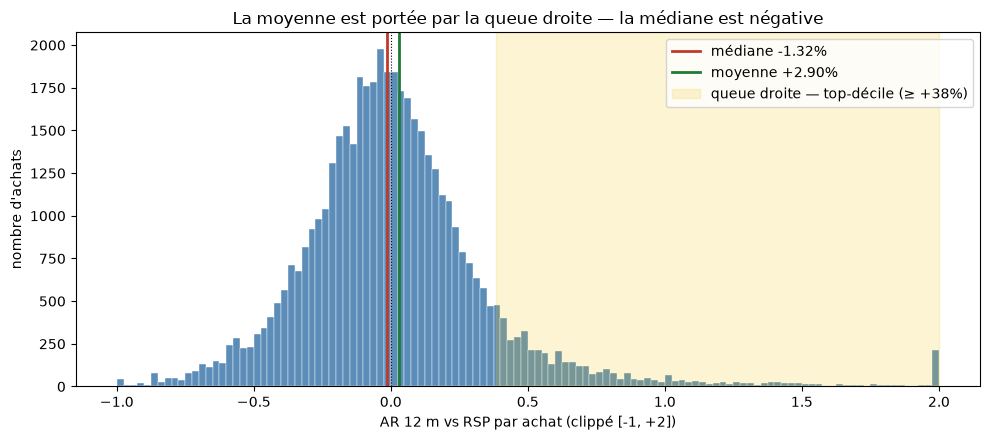

n = 46,283 | moyenne +2.90% | médiane -1.32% | seuil top-décile +38.48%


In [16]:
# Histogramme de car12 : moyenne (positive) vs médiane (négative), zone queue droite
car12 = buys['car12'].dropna()
moy, med = car12.mean(), car12.median()
q90 = car12.quantile(0.90)
clip = car12.clip(-1.0, 2.0)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(clip, bins=120, color='#5B8DB8', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', lw=0.8, ls=':')
ax.axvline(med, color='#C0392B', lw=2, label=f'médiane {med:+.2%}')
ax.axvline(moy, color='#1E7B34', lw=2, label=f'moyenne {moy:+.2%}')
ax.axvspan(q90, 2.0, color='#F1C40F', alpha=0.18,
           label=f'queue droite — top-décile (≥ {q90:+.0%})')
ax.set_xlabel("AR 12 m vs RSP par achat (clippé [-1, +2])")
ax.set_ylabel("nombre d'achats")
ax.set_title("La moyenne est portée par la queue droite — la médiane est négative")
ax.legend()
plt.tight_layout(); plt.show()

print(f"n = {len(car12):,} | moyenne {moy:+.2%} | médiane {med:+.2%} | seuil top-décile {q90:+.2%}")

**Lecture du graphe.**

- Le gros de la masse est **collé à zéro, légèrement à gauche** : la médiane est **négative** (≈ **−1,32 %**) → l'achat *typique* sous-performe RSP sur 12 mois.
- La moyenne (**+2,90 %**) est **à droite de la médiane** : elle n'est pas représentative du trade central, elle est **tirée par la queue droite** (zone jaune).
- Autrement dit : beaucoup de petits perdants, une minorité de très gros gagnants. C'est une **loterie à queue droite**, pas une stratégie à fort taux de réussite.

### 2.3 D'où vient la moyenne ? Décomposition par le top-décile

- Mesure : la part des **gains positifs** captée par le **top-décile** de `car12`, et la moyenne **une fois ce top-décile retiré**.
- Seuil : `q90` = quantile 0,90 de `car12` (frontière du top-décile).
- Lecture : si retirer 10 % des achats fait basculer la moyenne en franchement négatif, alors l'edge **n'est pas** un taux de réussite — il est concentré dans la queue.

In [17]:
# Décomposition de la moyenne : poids du top-décile dans les gains, moyenne sans lui
c = buys['car12'].dropna()
srt = np.sort(c.values)[::-1]          # tri décroissant
k = len(srt) // 10                      # taille du top-décile
seuil = c.quantile(0.90)
part_top = srt[:k].sum() / c[c > 0].sum()   # part des gains positifs captée par le top-décile
moy_sans_top = srt[k:].mean()               # moyenne après retrait du top-décile
sk = c.skew()

print(f"Achats avec AR 12 m mesurable : {len(c):,}")
print(f"Seuil top-décile (q90 de car12)  : {seuil:+.2%}")
print(f"Part des GAINS positifs captée par le top-décile : {part_top:.0%}")
print(f"Moyenne SANS le top-décile        : {moy_sans_top:+.2%}")
print(f"Skewness de car12                 : {sk:.1f}")

Achats avec AR 12 m mesurable : 46,283
Seuil top-décile (q90 de car12)  : +38.48%
Part des GAINS positifs captée par le top-décile : 61%
Moyenne SANS le top-décile        : -6.42%
Skewness de car12                 : 17.7


**Lecture de la décomposition.**

- Le **top-décile** des achats (CAR12 ≥ **+38 %**) capte à lui seul **≈ 61 %** de *tous* les gains positifs : l'edge est concentré dans une minorité d'achats.
- En retirant ce top-décile, la moyenne des **90 % restants** tombe à **−6,42 %** : sans la queue, copier le Congrès *perd* franchement contre RSP.
- Skewness ≈ **17,7** : distribution extrêmement asymétrique à droite — confirmation chiffrée du "loterie".
- **On ne gagne pas par taux de réussite** (% > 0 sous 50 %, médiane négative), on gagne *si et seulement si* on attrape les rares très gros coups.

### Verdict 2

- **Signal brut : oui, mais c'est une loterie à queue droite.** À 12 m vs RSP : moyenne **+2,90 %**, médiane **−1,32 %**, **47,7 %** d'achats gagnants, skew **17,7**.
- **Le benchmark change le niveau, pas la nature.** vs SPY la moyenne 12 m n'est que **+0,55 %** (méd. −3,67 %), vs secteur **+1,46 %** (méd. −1,70 %) : RSP est le repère le plus *honnête* (il ne soustrait pas la prime méga-caps qui porte le signal) et le plus *favorable*, mais dans les trois cas la médiane est **négative** et % > 0 **sous 50 %**.
- **L'edge est dans le top-décile.** Il capte **≈ 61 %** des gains positifs ; sans lui, la moyenne des 90 % restants est **−6,42 %**.
- **Conséquence pour la suite.** Une moyenne positive portée par une queue n'est pas exploitable *telle quelle* : un portefeuille doit (a) capter cette queue (pondération, horizon) et (b) prouver que ce n'est pas du beta marché déguisé. C'est l'objet des Parties 3-4.

## 3. Où le signal se concentre (coupes)

La Partie 2 a établi un edge agrégé (CAR 12 m vs RSP **+2,90 %**) extrêmement asymétrique : le haut de la distribution porte tout, le reste perd. On dissèque ici **où** se loge cet edge et **où** il faudrait aller le chercher.

- **Coupes** : on découpe les achats par caractéristique (chambre, parti, taille, profil de déposant, durée, commission clé, timing) et on lit le CAR 12 m sur chaque sous-population.
- **Concentration** : à l'intérieur du top-décile (les « jackpots »), on identifie les **tickers**, **secteurs** et **membres** qui portent les gains.
- **Robustesse** : on demande si ce qu'on voit est un *edge informationnel* ou seulement du *beta de style* et l'effet de *quelques individus* — via placebo, résidualisation secteur×année et **t honnête (clusterisé)**.

### 3.0 Méthode — la coupe ET le t honnête

Pour chaque coupe on regarde un profil **multi-métriques** (toutes calculées dans la cellule 3.1) :

- **n** : nombre d'achats avec CAR 12 m mesurable.
- **rdt brut** : rendement 12 m du titre, sans benchmark (`raw12`).
- **CAR vs RSP** : rendement anormal 12 m contre l'équipondéré RSP (= notre signal, `car12`).
- **CAR vs secteur** : même chose contre l'ETF SPDR du secteur GICS (`car12_sec`) — neutralise le tilt sectoriel.
- **hit rate** : part des achats à CAR > 0.
- **t naïf** puis **t clusterisé** (le point central, ci-dessous).

**Pourquoi le t naïf surestime.** Le t naïf vaut `moyenne / (σ / √n)`. Ce qui est supposé : que les n CAR sont **indépendants**. Ils ne le sont pas, pour deux raisons :

- **Fenêtres chevauchantes** : deux achats du même mois sur des titres corrélés partagent une grande part de leur trajectoire 12 m → leurs CAR sont corrélés.
- **Trades d'un même membre corrélés** : un membre qui achète 400 fois NVDA/AVGO/AMZN génère 400 CAR quasi-redondants ; le t naïf les compte comme 400 observations indépendantes et **gonfle √n**.

**Le t clusterisé par membre** corrige cela : on **moyenne d'abord le CAR par membre** (un membre = une observation), puis `t = moy_membres / (σ_membres / √#membres)`. Avec ~260 membres au lieu de ~46 000 achats, le √n s'effondre de plusieurs ordres et le t devient honnête. On retient le t clusterisé comme arbitre.

### 3.1 Profil par coupe

- **Médianes-pivot** (calculées sur l'échantillon) : taille `size_usd`, nombre de trades par membre, durée de détention (entrée→sortie règle Ramify).
- **Commission clé** : flag point-in-time `key_at(bio, year, keymap)` — siège dans Finance/Ways&Means/Banking/Armed Services/Intelligence à l'année du trade.
- **Timing** : on compare l'entrée à la date *filed* (notre règle exploitable) vs l'entrée à la date *traded* (information non disponible en temps réel, borne supérieure du signal).

In [18]:
# socle commun aux 4 sous-sections : car12, flag key PIT, médianes-pivot
b = buys.dropna(subset=['car12']).copy()
b['key']  = [key_at(x, f.year, keymap) for x, f in zip(b['bioguide'], b['filed'])]
b['cham'] = b['chamber'].astype(str).str.lower()
b['par']  = b['party'].astype(str).str.upper().str[0]
b['hold'] = (b['exit_d'] - b['filed']).dt.days          # durée de détention (règle Ramify)
amed = b['size_usd'].median()
ntr  = b.groupby('bioguide')['car12'].transform('size')  # nb de trades du membre
nmed = b.groupby('bioguide').size().median()
hmed = b['hold'].median()
print(f'pivots — taille médiane {amed:,.0f}$ | trades/membre médian {nmed:.0f} | détention médiane {hmed:.0f} j')

# rendement brut 12 m (sans benchmark) et CAR vs secteur, par achat
def raw_col(sub):
    out=[]
    for t,f in zip(sub['ticker'],sub['filed']):
        if t not in panel.columns: out.append(np.nan); continue
        px=panel[t].dropna(); i=px.index.searchsorted(pd.Timestamp(f)); j=i+252
        out.append(px.iloc[j]/px.iloc[i]-1.0 if (i<len(px) and j<len(px) and px.iloc[i]>0) else np.nan)
    return np.array(out)
b['raw12']    = raw_col(b)
b['car12_sec']= abn_col(b, RSP, 252, use_sector=True)
# entrée datée 'traded' (borne sup. du signal, non exploitable en temps réel)
b['car12_traded'] = abn_col(b.assign(filed=b['traded']), RSP, 252)

pivots — taille médiane 1,001$ | trades/membre médian 28 | détention médiane 183 j


In [19]:
# t naïf vs t clusterisé par membre
def t_naif(s):
    s=s.dropna(); return s.mean()/(s.std(ddof=1)/np.sqrt(len(s))) if len(s)>1 else np.nan
def t_cluster(sub, col='car12'):
    m=sub.dropna(subset=[col]).groupby('bioguide')[col].mean().dropna()
    return m.mean()/(m.std(ddof=1)/np.sqrt(len(m))) if len(m)>=2 else np.nan
def hit(s):
    s=s.dropna(); return (s>0).mean() if len(s) else np.nan

COUPES=[('Sénat',b['cham'].eq('senate')),('House',b['cham'].eq('house')),
        ('Républicains',b['par'].eq('R')),('Démocrates',b['par'].eq('D')),
        ('Gros (>méd)',b['size_usd']>amed),('Petits (<=méd)',b['size_usd']<=amed),
        ('Prolifiques',ntr.values>nmed),('Rares',ntr.values<=nmed),
        ('Détent. courte',b['hold']<=hmed),('Détent. longue',b['hold']>hmed),
        ('Commission clé',b['key']),('Hors commission',~b['key']),
        ('Entrée=filed',pd.Series(True,index=b.index))]
rows=[]
for nm,msk in COUPES:
    sub=b[np.asarray(msk)]; s=sub['car12']
    rows.append({'coupe':nm,'n':int(s.notna().sum()),'#mem':int(sub.dropna(subset=['car12']).groupby('bioguide').ngroups),'raw12':sub['raw12'].mean(),
                 'CAR12':s.mean(),'CAR_sec':sub['car12_sec'].mean(),'hit':hit(s),
                 't_naïf':t_naif(s),'t_clust':t_cluster(sub)})
s_tr=b['car12_traded']
rows.append({'coupe':'Entrée=traded','n':int(s_tr.notna().sum()),'#mem':int(b.dropna(subset=['car12_traded']).groupby('bioguide').ngroups),'raw12':np.nan,
             'CAR12':s_tr.mean(),'CAR_sec':np.nan,'hit':hit(s_tr),
             't_naïf':t_naif(s_tr),'t_clust':t_cluster(b,'car12_traded')})
T31=pd.DataFrame(rows)
d=T31.copy()
for c in ['raw12','CAR12','CAR_sec','hit']: d[c]=d[c].map(lambda x:f'{x:+.2%}' if pd.notna(x) else '—')
for c in ['t_naïf','t_clust']: d[c]=d[c].map(lambda x:f'{x:+.2f}' if pd.notna(x) else '—')
print(d.to_string(index=False))

          coupe     n  #mem   raw12  CAR12 CAR_sec     hit t_naïf t_clust
          Sénat  4804    52 +18.24% +3.25%  +2.41% +47.69%  +6.39   +1.80
          House 41479   191 +15.67% +2.86%  +1.35% +47.75% +10.45   +1.54
   Républicains 20608   139 +16.33% +2.95%  +1.61% +47.90%  +8.27   -0.93
     Démocrates 25660    99 +15.62% +2.86%  +1.34% +47.61%  +8.16   +3.30
    Gros (>méd) 10815   163 +14.93% +2.79%  +0.66% +49.13%  +6.15   +0.95
 Petits (<=méd) 35468   211 +16.25% +2.93%  +1.71% +47.32%  +9.88   +1.26
    Prolifiques 45294   118 +15.94% +2.89%  +1.46% +47.81% +11.36   +1.34
          Rares   989   121 +15.92% +3.33%  +1.70% +44.89%  +2.29   +1.77
 Détent. courte 23216   148 +14.36% +2.20%  +0.60% +46.61%  +5.95   -0.36
 Détent. longue 23067   234 +17.53% +3.60%  +2.33% +48.89% +10.63   +2.50
 Commission clé 26373   105 +16.38% +3.95%  +2.18% +48.08% +10.64   +1.41
Hors commission 19910   163 +15.36% +1.51%  +0.51% +47.30%  +4.81   +2.11
   Entrée=filed 46283   239 +15.94% +2

**Lecture 3.1.**

- **La commission clé domine** : CAR 12 m **+3,95 %** *vs* **+1,51 %** hors commission — l'edge est plus de **2,5×** plus fort quand le membre siège dans un comité informé. C'est la coupe la plus tranchée du tableau.
- **Sénat > House** sur le CAR brut (+3,25 % vs +2,86 %) et persiste un peu mieux au clustering (t_clust **+1,80** vs +1,54).
- **Détention longue** (au-delà de la médiane de détention) capte plus d'edge (+3,60 %, t_clust **+2,50**) — laisser courir paie.
- **Mais regarde l'effondrement naïf→clusterisé.** Commission clé : t **+10,64 → +1,41**. Sénat : **+6,39 → +1,80**. Républicains : **+8,27 → −0,93** (le signe s'inverse !). Une fois qu'on compte les membres et non les trades, la quasi-totalité des « significativités » fond — signe que peu d'individus portent le résultat.
- **Volume / activité** (coupe *Prolifiques vs Rares*, par nombre de trades du membre) : quasi aucun écart de CAR (+2,89 % vs +3,33 %) — trader beaucoup n'améliore **pas** la qualité par trade. La colonne **#mem** donne le nombre de membres (clusters) derrière chaque ligne — c'est le $n$ du $t$ clusterisé.
- Le **timing** apporte peu : entrer à *traded* (info parfaite) ne donne que **+2,70 %** vs **+2,90 %** à *filed* — la latence de déclaration ne détruit pas le signal.

### 3.2 Concentration ticker & secteur

- On définit le **top-décile** des achats : `car12 >= quantile 0,90`. Ce sont les « jackpots ».
- Par **ticker** et par **secteur GICS** dans ce top-décile : nombre de jackpots, CAR moyen, et **part des gains positifs totaux** (`somme des CAR du groupe / somme de tous les CAR > 0`).
- Lecture : si une poignée de noms tech monopolise la part des gains, l'edge n'est pas diffus mais un pari concentré.

In [20]:
q90=b['car12'].quantile(0.90); top=b[b['car12']>=q90]; tot_pos=b.loc[b['car12']>0,'car12'].sum()
print(f'top-décile : car12 >= {q90:+.1%} | {len(top):,} achats')
tk=top.groupby('ticker').agg(jackpots=('car12','size'),CAR_moy=('car12','mean'),gains=('car12','sum'))
tk['part_gains']=tk['gains']/tot_pos; tk=tk.sort_values('gains',ascending=False).head(10)
dt=tk.copy(); dt['CAR_moy']=dt['CAR_moy'].map('{:+.0%}'.format); dt['part_gains']=dt['part_gains'].map('{:.1%}'.format)
print('\nTICKERS (top-décile) :'); print(dt.drop(columns='gains').to_string())
sec=top.dropna(subset=['sector_gics']).groupby('sector_gics').agg(jackpots=('car12','size'),CAR_moy=('car12','mean'),gains=('car12','sum'))
sec['part_gains']=sec['gains']/tot_pos; sec=sec.sort_values('gains',ascending=False).head(6)
ds=sec.copy(); ds['CAR_moy']=ds['CAR_moy'].map('{:+.0%}'.format); ds['part_gains']=ds['part_gains'].map('{:.1%}'.format)
print('\nSECTEURS (top-décile) :'); print(ds.drop(columns='gains').to_string())
print(f"\nNVDA seul = {tk['part_gains'].iloc[0]:.1%} des gains positifs | top-10 tickers = {tk['part_gains'].sum():.1%}")

top-décile : car12 >= +38.5% | 4,629 achats

TICKERS (top-décile) :
        jackpots CAR_moy part_gains
ticker                             
NVDA         171   +120%       3.1%
SNDK           9  +1527%       2.1%
DAIUF          9  +1377%       1.9%
MU            41   +239%       1.5%
AONC           9   +728%       1.0%
WFRD          16   +373%       0.9%
URBN          54   +106%       0.9%
AMZN          87    +64%       0.8%
AVGO          60    +82%       0.7%
NFLX          63    +77%       0.7%

SECTEURS (top-décile) :
                        jackpots CAR_moy part_gains
sector_gics                                        
Information Technology      1348   +104%      21.2%
Industrials                  568    +96%       8.3%
Consumer Discretionary       592    +77%       6.9%
Health Care                  450    +79%       5.4%
Financials                   527    +61%       4.9%
Energy                       303    +93%       4.3%

NVDA seul = 3.1% des gains positifs | top-10 tickers = 13.

**Lecture 3.2.**

- **Un seul titre, NVDA**, capte **3,1 %** de tous les gains positifs (171 jackpots, CAR moyen +120 %). Le **top-10 des tickers** en capte **13,6 %**.
- Les CAR moyens vertigineux de SNDK (+1527 %), DAIUF (+1377 %) ou AONC (+728 %) sont des **micro-caps / situations spéciales** sur 9 jackpots chacun — bruit illiquide, non réplicable à l'échelle.
- Côté **secteurs**, **Information Technology** porte à lui seul **21,2 %** des gains positifs (1348 jackpots, CAR moyen +104 %). Le signal est massivement un **pari tech**.
- Conséquence : l'edge agrégé n'est pas diffus ; il est porté par une **poignée de méga-caps tech** et une longue queue de micro-caps spéculatives.

### 3.3 Concentration membre

- Pour chaque membre avec **≥ 30 achats** : CAR 12 m moyen, nombre de jackpots placés (achats dans le top-décile) et **part des jackpots totaux**.
- On regarde le **top** et le **bottom** par CAR moyen, puis **qui place le plus de jackpots**.

In [21]:
gm=b.groupby('bioguide').agg(name=('name','first'),n=('car12','size'),CAR_moy=('car12','mean'),
                            jack=('car12',lambda s:(s>=q90).sum()))
gm=gm[gm['n']>=30]; gm['part_jack']=gm['jack']/len(top)
print(f'membres avec >=30 achats : {len(gm)}')
def show(g):
    d=g.copy(); d['CAR_moy']=d['CAR_moy'].map('{:+.1%}'.format); d['part_jack']=d['part_jack'].map('{:.1%}'.format)
    print(d[['name','n','CAR_moy','jack','part_jack']].to_string())
print('\nTOP CAR moyen :');   show(gm.sort_values('CAR_moy',ascending=False).head(8))
print('\nBOTTOM CAR moyen :');show(gm.sort_values('CAR_moy').head(8))
jm=gm.sort_values('jack',ascending=False).head(8)
print('\nPLUS de jackpots :');show(jm)
print(f"\ntop-8 placeurs de jackpots = {jm['part_jack'].sum():.1%} des jackpots | Khanna seul = {jm['part_jack'].iloc[0]:.1%}")

membres avec >=30 achats : 118

TOP CAR moyen :
                              name    n CAR_moy  jack part_jack
bioguide                                                       
B001292   Donald Sternoff Beyer Jr  354  +51.4%    69      1.5%
S001198               Dan Sullivan   44  +46.9%    21      0.5%
M001236                  Tim Moore   69  +23.1%    18      0.4%
G000590              Mark Dr Green  257  +20.3%    68      1.5%
G000596     Marjorie Taylor Greene  423  +17.7%    94      2.0%
M001190           Markwayne Mullin  195  +15.4%    36      0.8%
M001198          Roger W. Marshall   47  +12.9%    15      0.3%
W000821            Bruce Westerman   96  +12.6%    25      0.5%

BOTTOM CAR moyen :
                                    name    n CAR_moy  jack part_jack
bioguide                                                             
S001189                     Austin Scott   35  -29.1%     3      0.1%
M001203                   Tom Malinowski  112  -28.1%     0      0.0%
N000192     

**Lecture 3.3.**

- **Une poignée de personnes fabrique les jackpots.** Les **8 plus gros placeurs** concentrent **64,7 %** de tous les jackpots ; **Ro Khanna seul en place 31,6 %** (1464 jackpots) — mais son CAR moyen n'est que **+2,6 %** : il achète beaucoup de tech, donc beaucoup de queues hautes par construction, pas par sélection fine.
- Les **meilleurs CAR moyens** sont rares et fragiles : Beyer +51 % (354 achats), Sullivan +47 % (44 achats), Greene +18 % (423 achats).
- Le **bottom** existe symétriquement (Austin Scott −29 %, Malinowski −28 %) : il n'y a pas que des gagnants.
- Combiné à 3.2 : **un petit nombre de titres et un petit nombre de membres** expliquent l'essentiel des gains. C'est exactement ce qu'un t clusterisé doit pénaliser.

### 3.4 Robustesse — edge informationnel, ou beta + quelques personnes ?

Trois tests adverses.

- **(a) Placebo achats vs ventes.** Si le signal est *directionnel* (info → le membre achète ce qui va monter), alors les **grosses ventes** devraient *sous-performer* (il vend ce qui va baisser). Si au contraire les gros achats ET les grosses ventes montent pareil, c'est un **tilt de style** (le membre trade des titres qui montent, point), pas une lecture directionnelle.
- **(b) Commission clé résidualisée.** On teste key vs hors commission par **Welch t** (variances inégales), d'abord sur le CAR brut, puis sur le **CAR résidualisé par secteur×année** (on retire la moyenne de chaque cellule secteur×année). Si l'écart survit, ce n'est pas qu'un effet « les membres de commission tradent plus de tech en bonne année ».
- **(c) Clustering.** t naïf vs t clusterisé pour les deux coupes vedettes (« ≥ 250 k$ » et « commission clé »).

In [22]:
# (a) PLACEBO : gros achats vs grosses ventes (top-décile de taille de chaque côté)
big_buys=b[b['size_usd']>b['size_usd'].quantile(0.90)]['car12'].dropna()
sl=df[(df['op']=='sell')&df['ticker'].notna()].copy(); sl['size_usd']=pd.to_numeric(sl['size_usd'],errors='coerce')
big_sells=sl[sl['size_usd']>sl['size_usd'].quantile(0.90)]
cs=abn_col(big_sells,RSP,252); cs=cs[~np.isnan(cs)]
print(f'(a) gros ACHATS  CAR12 {big_buys.mean():+.2%} (n={len(big_buys):,})')
print(f'    grosses VENTES CAR12 {cs.mean():+.2%} (n={len(cs):,})  -> les deux montent => tilt de style')

# (b) commission clé : Welch t brut puis résidualisé secteur x année
bb=b.dropna(subset=['car12','sector_gics']).copy(); bb['yr']=bb['filed'].dt.year
bb['resid']=bb['car12']-bb.groupby(['sector_gics','yr'])['car12'].transform('mean')
k=bb[bb['key']]; h=bb[~bb['key']]
wb=stats.ttest_ind(k['car12'],h['car12'],equal_var=False); wr=stats.ttest_ind(k['resid'],h['resid'],equal_var=False)
print(f"\n(b) Welch key vs hors  BRUT  diff {k['car12'].mean()-h['car12'].mean():+.2%}  t={wb.statistic:+.2f}")
print(f"                       RÉSID diff {k['resid'].mean()-h['resid'].mean():+.2%}  t={wr.statistic:+.2f}")

# (c) clustering sur les deux coupes vedettes
print()
for nm,sub in [('>=250k$',b[b['size_usd']>=250000]),('Commission clé',b[b['key']])]:
    print(f'(c) {nm:14s} n={len(sub):6,d}  t_naïf {t_naif(sub["car12"]):+.2f}  ->  t_clust {t_cluster(sub):+.2f}')

(a) gros ACHATS  CAR12 +4.16% (n=3,579)
    grosses VENTES CAR12 +4.49% (n=4,507)  -> les deux montent => tilt de style

(b) Welch key vs hors  BRUT  diff +2.30%  t=+4.83
                       RÉSID diff +2.27%  t=+4.92

(c) >=250k$        n=   691  t_naïf +2.63  ->  t_clust -0.11
(c) Commission clé n=26,373  t_naïf +10.64  ->  t_clust +1.41


**Lecture 3.4.**

- **(a) Placebo — c'est un tilt de style, pas de la direction.** Gros achats **+4,16 %** ; grosses ventes **+4,49 %**. Les deux montent **autant** : les membres tradent des titres qui montent (tech), qu'ils achètent OU qu'ils vendent. Le côté « ils vendent ce qui va baisser » n'apparaît pas — donc pas de lecture directionnelle exploitable, juste une exposition de style.
- **(b) Commission clé survit à la résidualisation.** Welch brut diff **+2,30 %** (t **+4,83**) ; résidualisé secteur×année diff **+2,27 %** (t **+4,92**). L'écart key/hors n'est PAS qu'un artefact « plus de tech en bonne année » — il y a un résidu d'information lié au comité. C'est le seul effet qui tient à peu près.
- **(c) Clustering = couperet.** « ≥ 250 k$ » : t naïf **+2,63 → t clust −0,11** (significativité naïve **détruite**, signe inversé). « Commission clé » : t naïf **+10,64 → +1,41** (chute sous le seuil). La plupart des significativités naïves venaient de **quelques individus prolifiques**, pas d'un edge large.

### Verdict 3 — où chercher, et ce qui s'évapore

**Où le signal se concentre (à exploiter) :**
- **Commission clé** : CAR 12 m **+3,95 %** vs **+1,51 %** hors — l'effet le plus net, et le seul à survivre à la résidualisation secteur×année (Welch t **+4,92**, diff résiduelle **+2,27 %**).
- **Sénat** légèrement > House (CAR +3,25 % vs +2,86 % ; t_clust +1,80 vs +1,54) et **détention longue** (+3,60 %, t_clust +2,50).
- **Concentration extrême** : NVDA seul = **3,1 %** des gains positifs, top-10 tickers = **13,6 %**, secteur IT = **21,2 %** ; côté humain, **8 membres = 64,7 %** des jackpots (Khanna **31,6 %** à lui seul).

**Ce qui s'évapore sous les tests honnêtes :**
- **Clustering par membre** : t naïf → t clust effondre tout. « ≥ 250 k$ » **+2,63 → −0,11** (signe inversé), « commission clé » **+10,64 → +1,41**, Républicains **+8,27 → −0,93**. La significativité naïve venait d'une **poignée d'individus**, pas d'un edge diffus.
- **Placebo** : gros achats **+4,16 %** ≈ grosses ventes **+4,49 %** → **tilt de style (tech), pas de direction**.

**Conclusion :** l'edge réel se résume à **un résidu d'information « commission clé » au Sénat, porté par une poignée de tickers tech et de membres**. Hors de cette niche, ce que les coupes montrent est essentiellement du **beta de style** et l'effet de **quelques personnes** — d'où l'impératif, en Partie 4, de tester en portefeuille avec alpha factoriel plutôt qu'en CAR moyen.

## 4. Backtest rigoureux — suivre TOUT le Congrès

- **Question.** Avant de chercher un sous-ensemble ciblé (Partie 5), on teste l'hypothèse la plus naïve possible : **copier tous les achats** de tous les membres, sans aucune sélection.
- **Pourquoi ce détour.** Si « tout copier » battait déjà le marché, la sélection serait du raffinage marginal. On veut savoir si le signal *brut*, agrégé, contient de l'alpha — ou seulement du bêta.
- **Mécanisme du backtest (rappel, identique partout).**
  - *Entrée* : `filed + 1` jour ouvré (`lag_days=1`) — on n'agit qu'à partir de l'information publique, pas à la date de transaction.
  - *Sortie* : à la **vente déclarée** du même membre sur le même ticker si elle survient, sinon **+12 mois** (règle Ramify ; `horizon_months=12`).
  - *Coûts* : **20 bps** (`cost_bps=20`) appliqués à chaque variation de poids (achat + sortie).
  - *Rendements* : journaliers, **winsorisés à ±50 %** (clip dans `run_portfolio`) pour neutraliser les sauts de prix aberrants.
- **Ce qui est supposé** : pas de slippage au-delà des 20 bps, exécution au close, capital toujours pleinement investi sur les positions ouvertes (poids = part d'exposition, renormalisés chaque jour).

### 4.1 Variantes « copier tout » : CAGR / vol / Sharpe / maxDD

- **Trois pondérations** d'un même panier de positions (toutes les positions ouvertes le jour *t*) :
  - `equal` : poids égal par position (1/n) — vote égalitaire, surpondère les petits trades.
  - `size` : poids ∝ montant déclaré `size_usd` — suit la conviction en dollars.
  - `sqrt_size` : poids ∝ √`size_usd` — compromis (atténue la domination des gros tickets).
- **Métriques** (toutes annualisées, `ann_stats`) :
  - *CAGR* = (∏(1+r))^(252/jours) −1 : croissance composée nette.
  - *vol* = écart-type journalier × √252 : amplitude du risque.
  - *Sharpe* = (moyenne/écart-type) × √252 : rendement par unité de risque (ici **brut de RF**, comparable entre lignes).
  - *maxDD* = pire perte crête-creux de la courbe composée : douleur maximale.
- **Benchmarks** : `SPY` (cap-weighted), `RSP` (S&P 500 équi-pondéré, le bon comparable car les paniers Congrès sont quasi équi-pondérés), `60/40` = 0,6·SPY + 0,4·AGG (obligataire).
- **Limite** : la fenêtre couvre 2014–2026, dont 2026 partiel — les niveaux absolus héritent du régime haussier de la décennie.

In [23]:
# 4.1 — trois variantes « copier tout » vs benchmarks
WEIGHTINGS = ['equal', 'size', 'sqrt_size']
pos_all = build_positions(buys, df, horizon_months=12, sell_map=SELL_MAP)
nets = {w: run_portfolio(pos_all, panel, w, cost_bps=20, lag_days=1)['net'] for w in WEIGHTINGS}
ref_idx = nets['size'].index

# benchmarks alignés sur la fenêtre du portefeuille (60/40 = 0,6·SPY + 0,4·AGG)
spy_d = bench_daily(SPY, ref_idx)
rsp_d = bench_daily(RSP, ref_idx)
agg_d = bench_daily(etfp['AGG'], ref_idx)
b6040_d = 0.6 * spy_d + 0.4 * agg_d

series_4_1 = {**{f'copier-tout · {w}': nets[w] for w in WEIGHTINGS},
              'SPY': spy_d, 'RSP': rsp_d, '60/40': b6040_d}

tab41 = pd.DataFrame([{'CAGR': ann_stats(d)['CAGR'], 'vol': ann_stats(d)['vol'],
                       'Sharpe': ann_stats(d)['sharpe'], 'maxDD': ann_stats(d)['maxDD']}
                      for d in series_4_1.values()], index=list(series_4_1)).rename_axis('stratégie')
_F41 = {'CAGR': '{:+.2%}'.format, 'vol': '{:.2%}'.format, 'Sharpe': '{:.2f}'.format, 'maxDD': '{:.2%}'.format}
print(tab41.to_string(formatters=_F41))

                           CAGR    vol Sharpe   maxDD
stratégie                                            
copier-tout · equal     +10.60% 16.95%   0.68 -36.74%
copier-tout · size      +13.46% 18.18%   0.79 -31.53%
copier-tout · sqrt_size +11.34% 17.06%   0.72 -35.21%
SPY                     +14.13% 16.99%   0.86 -33.72%
RSP                     +11.69% 17.40%   0.72 -39.04%
60/40                    +9.50% 10.58%   0.91 -21.72%


**Lecture 4.1.**
- La meilleure variante est `size` : **CAGR +13,46 %**, **Sharpe 0,79**, maxDD −31,53 %. `equal` traîne (CAGR +10,60 %, Sharpe 0,68), `sqrt_size` est intermédiaire (+11,34 %, Sharpe 0,72).
- **Aucune variante ne bat SPY** : SPY fait **CAGR +14,13 %, Sharpe 0,86** — plus de rendement *et* plus de Sharpe que `size`, à vol comparable (16,99 % vs 18,18 %).
- Contre **RSP** (le comparable équi-pondéré), `size` gagne légèrement en rendement (+13,46 % vs +11,69 %) et en Sharpe (0,79 vs 0,72) — c'est là que vit le mince surcroît de performance.
- Le **60/40** a le meilleur Sharpe du tableau (0,91) grâce à sa vol moitié moindre (10,58 %), mais le plus faible CAGR (+9,50 %).
- *Indice* : un Sharpe sous SPY + une vol élevée suggèrent un portefeuille essentiellement **bêta**, sans prime nette — ce que 4.2 quantifie.

### 4.2 Famille ALPHA : la performance est-elle du bêta ou de l'alpha ?

- **Idée** : régresser le rendement *excédentaire* (rendement − RF) de chaque variante sur des facteurs de risque connus. Ce que les facteurs n'expliquent pas = l'intercept α.
- **Trois modèles emboîtés** (`factor_alpha`, erreurs **HAC Newey-West**, 5 lags, pour l'autocorrélation) :
  - *CAPM* : un facteur, `Mkt-RF` (marché).
  - *FF3* : + `SMB` (taille) + `HML` (value).
  - *FFC4* : + `Mom` (momentum) — le plus exigeant.
- **Symboles** : rₜ−RF = α + β·(Mkt-RF) + … + εₜ. α = sur-rendement annualisé *inexpliqué* ; β = sensibilité au marché ; t = α/écart-type(α) ; R² = part de variance expliquée.
- **Ce qui est supposé** : facteurs FF correctement spécifiés, relation linéaire, résidus stationnaires (HAC corrige l'hétéroscédasticité/autocorrélation).
- **Lecture** : un α ne compte que si **|t| ≥ 2**. Un β proche de 1 + R² élevé = « c'est du marché déguisé ».
- **Limite** : l'alpha annualisé d'une série courte est bruyant ; le t (et non le signe de α) tranche.

In [24]:
# 4.2 — alpha CAPM / FF3 / FFC4 (t HAC), bêta marché, R²
tab42 = pd.DataFrame([{
    'variante': w,
    'aCAPM': factor_alpha(nets[w], factors, 'capm')['alpha_annuel'],
    'tCAPM': factor_alpha(nets[w], factors, 'capm')['alpha_t'],
    'aFF3':  factor_alpha(nets[w], factors, 'ff3')['alpha_annuel'],
    'tFF3':  factor_alpha(nets[w], factors, 'ff3')['alpha_t'],
    'aFFC4': factor_alpha(nets[w], factors, 'ffc4')['alpha_annuel'],
    'tFFC4': factor_alpha(nets[w], factors, 'ffc4')['alpha_t'],
    'beta':  factor_alpha(nets[w], factors, 'ffc4')['beta_marche'],
    'tbeta': factor_alpha(nets[w], factors, 'ffc4')['beta_t'],
    'R2':    factor_alpha(nets[w], factors, 'ffc4')['R2'],
} for w in WEIGHTINGS]).set_index('variante')
_F42 = {c: ('{:+.2%}'.format if c.startswith('a') else ('{:+.2f}'.format if c.startswith('t') else '{:.2f}'.format))
        for c in tab42.columns}
print(tab42.to_string(formatters=_F42))

           aCAPM tCAPM   aFF3  tFF3  aFFC4 tFFC4 beta   tbeta   R2
variante                                                          
equal     -2.33% -1.74 -1.77% -1.68 -1.24% -1.28 0.91 +102.49 0.96
size      +0.48% +0.26 +0.75% +0.42 +1.00% +0.57 0.95  +88.13 0.87
sqrt_size -1.60% -1.28 -1.13% -1.04 -0.66% -0.65 0.92 +123.96 0.95


**Lecture 4.2.**
- **β marché plein** : 0,91 (`equal`) à 0,95 (`size`), toujours **massivement significatif** (t de +88 à +124) avec un **R² de 0,87 à 0,96**. Le portefeuille *est* le marché à ~9/10ᵉ.
- **Aucun alpha significatif** — tous les |t| < 2 :
  - `size` : α positifs mais minuscules et non significatifs — CAPM **+0,48 % (t +0,26)**, FF3 **+0,75 % (t +0,42)**, FFC4 **+1,00 % (t +0,57)**.
  - `equal` : α **négatifs** — FFC4 **−1,24 % (t −1,28)** ; `sqrt_size` FFC4 **−0,66 % (t −0,65)**.
- En passant du CAPM au FFC4, l'alpha de `size` *monte* (+0,48 % → +1,00 %) : le momentum absorbe un peu de risque, mais jamais assez pour rendre l'alpha significatif.
- **Conclusion** : la « surperformance » vs RSP de 4.1 n'est pas de l'alpha — c'est du bêta non factorisé, dans le bruit.

### 4.3 Famille SHARPE : qualité du risque ajusté

- **Complément au Sharpe brut** — quatre angles :
  - *Sharpe* = (moy/écart-type)·√252 : rendement par unité de risque total.
  - *PSR* (Probabilistic Sharpe Ratio) : probabilité que le vrai Sharpe > 0 compte tenu de **l'asymétrie et du kurtosis** de la série (corrige le Sharpe naïf des queues épaisses).
  - *Sortino* = (moy/écart-type des **seuls jours négatifs**)·√252 : ne pénalise que le risque baissier.
  - *IR vs RSP* (Information Ratio) = moyenne(r−RSP)/écart-type(r−RSP)·√252 : qualité du sur-rendement *actif* contre l'équi-pondéré.
- **Ce qui est supposé** : RSP est le bon benchmark de tracking (même structure équi-pondérée que les paniers).
- **Lecture** : on cherche une ligne qui domine SPY sur *plusieurs* angles. Un PSR ≈ 1 dit seulement « Sharpe > 0 quasi certain » (série longue), pas « Sharpe élevé ».
- **PSR vs DSR (à ne pas confondre)** : le **PSR** compare le Sharpe à **zéro** ; le **DSR** (Deflated Sharpe) le compare au **meilleur Sharpe attendu par pur hasard quand on teste *n* stratégies** (seuil relevé). Un PSR ≈ 1 ne dit donc **rien** sur la survie au data-mining — seul le DSR tranche. Il n'est **pas** calculable ici (une seule stratégie par ligne) ; il le sera en **Partie 5.4** sur la grille (44 essais).

In [25]:
# 4.3 — Sharpe / PSR / Sortino / IR vs RSP (variantes + SPY + RSP)
sharpe_set = {**{w: nets[w] for w in WEIGHTINGS}, 'SPY': spy_d, 'RSP': rsp_d}
tab43 = pd.DataFrame([{'Sharpe': sharpe(d), 'PSR': psr(d), 'Sortino': sortino(d),
                       'IR_vs_RSP': info_ratio(d, rsp_d)}
                      for d in sharpe_set.values()], index=list(sharpe_set)).rename_axis('stratégie')
_F43 = {'Sharpe': '{:.2f}'.format, 'PSR': '{:.2f}'.format, 'Sortino': '{:.2f}'.format, 'IR_vs_RSP': '{:+.2f}'.format}
print(tab43.to_string(formatters=_F43))

          Sharpe  PSR Sortino IR_vs_RSP
stratégie                              
equal       0.68 0.99    0.83     -0.25
size        0.79 1.00    0.98     +0.19
sqrt_size   0.72 0.99    0.87     -0.07
SPY         0.86 1.00    1.05     +0.36
RSP         0.72 0.99    0.89       NaN


**Lecture 4.3.**
- **SPY domine** : Sharpe **0,86**, Sortino **1,05**, IR vs RSP **+0,36** — meilleur que toute variante Congrès sur chaque angle.
- La meilleure variante reste `size` (Sharpe **0,79**, Sortino **0,98**, IR vs RSP **+0,19**) : positive contre RSP, mais **sous SPY** partout.
- `equal` et `sqrt_size` ont un **IR vs RSP négatif** (−0,25 et −0,07) : elles détruisent de la valeur active contre l'équi-pondéré.
- Les **PSR ≈ 0,99–1,00** confirment seulement que les Sharpe sont *positifs* de façon quasi certaine (12 ans de données) — ce n'est **pas** un signe de supériorité ; aucune ligne ne dépasse SPY.
- **Bilan** : aucune pondération naïve ne domine le simple buy-and-hold SPY.

### 4.4 Test GRS joint : tous les alphas sont-ils nuls *ensemble* ?

- **Pourquoi GRS.** Les 4.2 testent les alphas un par un. Le test **Gibbons-Ross-Shanken** les teste **conjointement** : un seul test pour N portefeuilles, qui contrôle la corrélation entre eux et le data-mining implicite de regarder plusieurs colonnes.
- **Hypothèse nulle H0** : *tous* les alphas des N portefeuilles-test sont nuls simultanément (α₁ = … = αₙ = 0) — autrement dit, les facteurs FFC4 expliquent **entièrement** ces portefeuilles, il n'y a aucune prime résiduelle.
- **Portefeuilles-test NON CHEVAUCHANTS** : une partition **2×2** des achats par *chambre* × *commission* — {House, Sénat} × {clé, non-clé}, via `key_at`. Chaque achat tombe dans exactement une case → portefeuilles disjoints (prérequis pour un Σ résiduel inversible et non dégénéré). On reporte aussi la variante « 3 pondérations » à titre de robustesse.
- **Construction** (`grs_test`) : rendements **mensuels excédentaires** = resample 'ME', (1+r).prod()−1, moins RF mensualisé ; facteurs eux aussi composés au mois.
- **Statistique** : GRS suit une **F(N, T−N−L)** sous H0. Symboles : N = nb de portefeuilles, T = nb de mois, L = nb de facteurs.
- **Lecture** : **p < 0,05 → on rejette H0** = au moins un alpha non nul (du signal exploitable existe). **p ≥ 0,05 → on ne rejette pas** = compatible avec « tout est du bêta ».
- **Limite** : non-rejet ≠ preuve d'absence d'alpha ; c'est une absence de preuve d'alpha *agrégé sur ces découpes*.

In [26]:
# 4.4 — GRS sur partition 2x2 NON chevauchante : chambre x {clé, non-clé}
b = buys.copy()
b['key'] = [key_at(x, f.year, keymap) for x, f in zip(b['bioguide'], b['filed'])]
b['cham'] = b['chamber'].str.lower()
test_defs = {
    'House·clé':      (b['cham'].eq('house'))  & (b['key']),
    'House·non-clé':  (b['cham'].eq('house'))  & (~b['key']),
    'Sénat·clé':      (b['cham'].eq('senate')) & (b['key']),
    'Sénat·non-clé':  (b['cham'].eq('senate')) & (~b['key']),
}

def monthly_excess(daily, rf_m):
    m = (1 + daily).resample('ME').prod() - 1
    return m - rf_m.reindex(m.index)

rf_m = (1 + factors['RF']).resample('ME').prod() - 1
Fm = pd.DataFrame({c: (1 + factors[c]).resample('ME').prod() - 1 for c in ['Mkt-RF', 'SMB', 'HML', 'Mom']})

cols = {nm: monthly_excess(
            run_portfolio(build_positions(b[mask], df, 12, sell_map=SELL_MAP), panel, 'size', 20)['net'], rf_m)
        for nm, mask in test_defs.items()}
R = pd.DataFrame(cols).dropna()
res = grs_test(R, Fm)
print('Partition 2x2 (chambre x clé) : '
      f"GRS={res['GRS']:.3f}  p={res['p_value']:.3f}  N={res['N']}  T={res['T']}  L={res['L']}  (loi F à {res['N']},{res['T']-res['N']-res['L']} ddl)")

# robustesse : les 3 variantes de pondération comme portefeuilles-test
cols2 = {w: monthly_excess(nets[w], rf_m) for w in WEIGHTINGS}
res2 = grs_test(pd.DataFrame(cols2).dropna(), Fm)
print('Robustesse 3-pondérations    : '
      f"GRS={res2['GRS']:.3f}  p={res2['p_value']:.3f}  N={res2['N']}  T={res2['T']}  L={res2['L']}  (loi F à {res2['N']},{res2['T']-res2['N']-res2['L']} ddl)")

Partition 2x2 (chambre x clé) : GRS=0.993  p=0.414  N=4  T=155  L=4  (loi F à 4,147 ddl)
Robustesse 3-pondérations    : GRS=0.966  p=0.411  N=3  T=155  L=4  (loi F à 3,148 ddl)


**Lecture 4.4.**
- Partition 2×2 (N=4 portefeuilles, T=155 mois, L=4 facteurs) : **GRS = 0,99**, **p = 0,41**.
- Robustesse 3-pondérations (N=3) : **GRS = 0,97**, **p = 0,41**.
- Dans les deux cas **p ≫ 0,05 → on NE rejette PAS H0** : les facteurs FFC4 expliquent ces portefeuilles, **aucun alpha conjoint** n'est détecté — *absence de preuve d'alpha, pas preuve de son absence*.
- C'est cohérent avec les |t| < 2 individuels de 4.2 : ni séparément, ni conjointement, le signal *brut agrégé* ne produit de prime.
- *Nuance* : ce test porte sur des paniers larges. Un sous-ensemble ciblé (membres pré-sélectionnés) peut concentrer un alpha que la moyenne dilue — c'est l'objet de la Partie 5.

### 4.5 Courbes d'équité (échelle log)

- Valeur composée nette des trois variantes vs SPY et RSP, base 1.
- **Échelle logarithmique** : une pente égale = un même rendement composé ; on lit la *forme* (drawdowns 2020, 2022) plutôt que le niveau absolu.

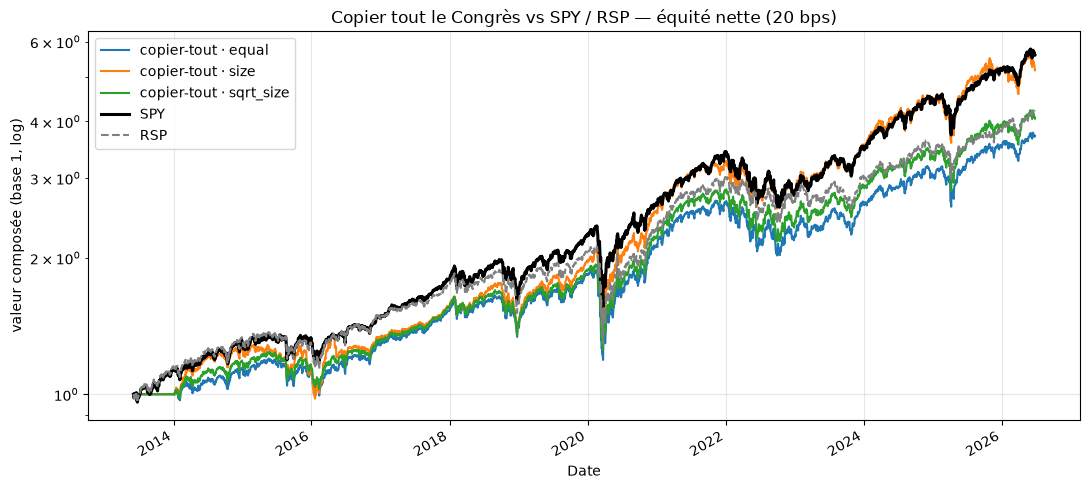

In [27]:
# 4.5 — equity curves nettes vs SPY / RSP (échelle log)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 5))
for w in WEIGHTINGS:
    (1 + nets[w]).cumprod().plot(ax=ax, label=f'copier-tout · {w}')
(1 + spy_d).cumprod().plot(ax=ax, label='SPY', lw=2.2, color='black')
(1 + rsp_d).cumprod().plot(ax=ax, label='RSP', lw=1.5, color='grey', ls='--')
ax.set_yscale('log')
ax.set_ylabel('valeur composée (base 1, log)')
ax.set_title('Copier tout le Congrès vs SPY / RSP — équité nette (20 bps)')
ax.legend(loc='upper left'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Lecture 4.5.**
- Les trois courbes Congrès suivent SPY de près — confirmation visuelle du **β ≈ 0,95 / R² ≥ 0,87** : c'est le même moteur de marché.
- `size` (la meilleure) reste **sous SPY** sur l'ensemble de la fenêtre ; aucune variante ne décroche durablement au-dessus du benchmark cap-weighted.
- Les creux (krach Covid 2020, baisse de taux 2022) sont communs à toutes les séries : pas de protection différenciée à la baisse.

### Verdict — Partie 4

- **« Copier tout le Congrès » ≈ détenir le marché.** β marché 0,91–0,95 (t +88 à +124), R² 0,87–0,96. La performance est du bêta, pas du signal.
- **Aucun alpha FFC4 significatif** : meilleure variante `size` → α FFC4 **+1,00 % (t +0,57)** ; `equal` **−1,24 % (t −1,28)** ; `sqrt_size` **−0,66 % (t −0,65)**. Tous |t| < 2.
- **Rien ne bat SPY** : SPY Sharpe **0,86** > `size` 0,79 > `sqrt_size` 0,72 ≈ RSP 0,72 > `equal` 0,68 ; et SPY CAGR **+14,13 %** > `size` +13,46 %.
- **GRS ne rejette pas H0** : partition 2×2 chambre×clé → **GRS 0,99, p 0,41** (N=4, T=155) ; robustesse 3-pondérations **GRS 0,97, p 0,41**. Pas d'alpha conjoint détectable.
- **Conclusion** : le signal brut agrégé est dilué — copier *tout le monde* ne paie pas. Il faut un sous-ensemble **CIBLÉ** (membres pré-sélectionnés sur un critère point-in-time). → **Partie 5**.

## 5. La sélection : 11 critères en walk-forward strict

- **Le problème posé par Ramify.** Plutôt que copier *tout* le Congrès (Partie 4, dilué), on veut **choisir K membres** dont les achats seront répliqués l'année suivante. La règle métier imposée :
  - on classe les membres **en fin d'année N** sur un critère de qualité ;
  - un membre n'est **éligible** que s'il a **≥ 10 trades clôturés** (sinon la statistique est du bruit) ;
  - **au moins la moitié** du panier doit siéger dans une **commission clé** (Finance, Banking, Armed Services, Intelligence, Ways and Means…) — contrainte d'information, *point-in-time* ;
  - les positions sont **laissées courir** (sortie = vente déclarée du membre, sinon 12 mois).
- **Walk-forward strict (zéro look-ahead).** *Look-ahead* = utiliser, dans la décision prise **fin année N**, une information qui n'existait pas encore à cette date (un rendement futur, une vente postérieure). On l'élimine intégralement. C'est le point non négociable.
  - Sélection construite **uniquement** sur des trades dont la **sortie ≤ 31/12 de l'année N** (`exit_d`), donc entièrement *réalisés* et *connus* à cette date.
  - Panier appliqué aux achats **filés en N+1** (`gate_buys` décale d'un an : `filed.year-1`).
  - Aucune information future n'entre dans le choix : c'est la seule façon honnête de simuler ce qu'un gérant aurait *réellement* pu faire.
- **Ce que cette partie répond.** Lequel des 11 critères sélectionne le mieux ? Le gain survit-il au choix de K ? Et surtout : tient-il une fois qu'on a **payé le coût des essais multiples** (deflated Sharpe) et qu'on regarde si les bons d'hier restent bons demain (persistance) ?

### 5.1 Les 11 critères de sélection

Notation commune. Pour un membre, soit $a_1,\dots,a_n$ ses **rendements anormaux réalisés** (vs RSP, colonne `tret`), $r_1,\dots,r_n$ ses rendements **bruts** (`traw`), $n$ son nombre de trades clôturés, $N$ le total de trades du groupe éligible, et $\bar S$ le Sharpe moyen du groupe. *Ce qui est supposé partout* : trades i.i.d. dans le temps (faux en pratique → t-stats optimistes), et que le passé réalisé informe le futur (l'hypothèse même qu'on teste).

- **c1 — hit rate.** Mesure : régularité. Formule : $\frac1n\sum \mathbb 1[a_i>0]$. Lecture : part de trades gagnants. *Faiblesse* : ignore la taille des gains/pertes (gagner souvent peu, perdre rarement beaucoup).
- **c2 — rendement brut moyen.** Mesure : performance absolue. Formule : $\frac1n\sum r_i$. Lecture : gain moyen par trade. *Faiblesse* : capte surtout le **bêta** (un marché haussier gonfle tout le monde).
- **c3 — rendement anormal moyen.** Mesure : skill net du marché. Formule : $\frac1n\sum a_i$. Lecture : surperf moyenne vs RSP. *Faiblesse* : dominé par quelques *outliers* (la queue droite de la Partie 2).
- **c4 — médiane de l'anormal.** Mesure : skill **robuste** aux outliers. Formule : $\mathrm{med}(a_i)$. Lecture : le trade « typique ». *Faiblesse* : jette précisément l'information de la queue, qui est où vit l'alpha du Congrès.
- **c5 — profit factor.** Mesure : asymétrie gains/pertes. Formule : $\sum_{a_i>0} a_i \big/ \big|\sum_{a_i\le 0} a_i\big|$ (plafonné à 10). Lecture : >1 = profitable. *Faiblesse* : instable et explosif sur petit $n$.
- **c6 — Sharpe de la série de trades.** Mesure : rendement par unité de risque. Formule : $\bar a/\sigma_a$. Lecture : qualité ajustée du risque. *Faiblesse* : sur 10–20 trades, **énorme** erreur d'estimation (le chanceux brille).
- **c7 — Shrunk Sharpe (Mauboussin).** Mesure : Sharpe **dégonflé** vers le groupe pour les petits échantillons. *Ce qui est supposé* : un Sharpe estimé sur peu de trades est en partie chance. Formule : $\frac{n}{n+k}\,\frac{\bar a}{\sigma_a} + \big(1-\frac{n}{n+k}\big)\bar S$ (ici $k{=}10$). Lecture : tire les « miraculés sur 10 trades » vers la moyenne. *Faiblesse* : le choix de $k$ est arbitraire.
- **c8 — Score UCB (*Upper Confidence Bound*, « borne de confiance supérieure » ; cadre des bandits manchots de Sutton-Barto) — critère « officiel ».** Mesure : Shrunk Sharpe **+ bonus d'exploration** pour les peu observés. Formule : $c7 + c\sqrt{\ln N / n}$ ($c{=}0{,}5$). Lecture : on récompense un bon membre **encore peu suivi** par une prime d'incertitude (« optimisme face à l'incertitude ») — pour ne pas l'écarter trop vite ($N$ = total de trades du groupe éligible, $n$ = ceux du membre). *Faiblesse* : le bonus peut faire remonter du bruit.
- **c9 — t-stat du membre.** Mesure : significativité de l'anormal moyen. Formule : $\bar a/(\sigma_a/\sqrt n)$. Lecture : skill *crédible* (combine taille d'effet et $n$). *Faiblesse* : t-stat naïf (pas de correction d'autocorrélation/clustering).
- **c10 — α CAPM du membre.** Mesure : surperf après **bêta marché**. *Ce qui est supposé* : un facteur (marché). Formule : ordonnée $\alpha$ de $R^e_t = \alpha + \beta\,\mathrm{Mkt}^e_t + \varepsilon_t$ (annualisée, HAC). Lecture : alpha « propre » du membre. *Faiblesse* : un seul facteur → confond style et skill.
- **c11 — α FFC4 du membre.** Mesure : surperf après **4 facteurs** (marché, taille, valeur, momentum). Formule : $\alpha$ de la régression Carhart. Lecture : l'alpha le plus exigeant. *Faiblesse* : **sur-paramétré** sur une courte série quotidienne d'un seul membre → $\alpha$ très bruité.
- **Score total (composite multi-critères).** Au-delà des 11 critères qui isolent *une* dimension chacun, on rapporte aussi un **score agrégé** = la **moyenne des rangs** (percentiles) du membre sur les critères risque-ajustés (c3, c6, c7, c9, c10). Idée : un bon membre doit bien se classer sur **plusieurs** angles à la fois — c'est la réponse directe à « scorer de toutes les manières » (on **combine** au lieu de choisir un critère unique). Il figure en dernière ligne du tableau 5.3.
- **Contrainte structurelle — commission clé (PIT).** Indépendamment du critère, le panier doit compter **≥ 50 % de membres en commission clé** *à la date de sélection* (`key_at`, point-in-time). C'est l'hypothèse économique de l'étude : l'information vient des commissions sensibles.

### 5.2 Scoreboard — une fiche de notes par membre

- On reconstruit d'abord une **série quotidienne nette par membre** (`build_all_member_series`) — nécessaire pour c10/c11 (régressions factorielles individuelles).
- Puis on calcule le tableau de notes **arrêté fin 2022** (`member_scores(..., 2022, ...)`) : une ligne par membre éligible, les 11 colonnes côte à côte.
- Lecture : on affiche le **top 6** trié par le critère officiel c8 (UCB), plus les comptes d'éligibilité.

In [28]:
# Serie quotidienne nette par membre (>=10 trades), puis scoreboard arrete fin 2022
member_daily = build_all_member_series(buys, df, panel)
sc22 = member_scores(buys, 2022, keymap, member_daily, factors)
n_elig = len(sc22); n_key = int(sc22['key'].sum())
print(f"membres notes (serie quotidienne, >=10 trades) : {len(member_daily)}")
print(f"fin 2022 -> eligibles : {n_elig} | dont commission cle : {n_key} ({n_key/n_elig:.0%})")

top6 = sc22.sort_values('c8_ucb', ascending=False).head(6)
show = top6[['name', 'n', 'key'] + CRITERIA].copy()
fmts = {'c1_hit':'{:.0%}'.format, 'c2_raw':'{:+.1%}'.format, 'c3_abn':'{:+.1%}'.format,
        'c4_med':'{:+.1%}'.format, 'c5_pf':'{:.2f}'.format, 'c6_sharpe':'{:.2f}'.format,
        'c7_shrunk':'{:.2f}'.format, 'c8_ucb':'{:.2f}'.format, 'c9_t':'{:+.2f}'.format,
        'c10_aCAPM':'{:+.1%}'.format, 'c11_aFFC4':'{:+.1%}'.format}
print('\nTop 6 fin 2022 (trie c8_ucb) :')
print(show.to_string(index=False, formatters=fmts))

membres notes (serie quotidienne, >=10 trades) : 176
fin 2022 -> eligibles : 123 | dont commission cle : 39 (32%)

Top 6 fin 2022 (trie c8_ucb) :
                   name  n   key c1_hit c2_raw c3_abn c4_med c5_pf c6_sharpe c7_shrunk c8_ucb  c9_t c10_aCAPM c11_aFFC4
           Justin Amash 16 False    69% +33.9% +14.1% +11.5% 10.00      0.65      0.39   0.79 +2.61     +5.5%     +6.2%
         Michael Garcia 13 False    92% +34.1% +29.0%  +3.5% 10.00      0.61      0.33   0.78 +2.20     +0.3%     +1.5%
Brenda Lulenar Lawrence 12 False    58% +78.3% +72.2% +21.7%  6.69      0.57      0.30   0.76 +1.97     +2.3%     +2.0%
           Cheri Bustos 13 False    54% +22.1% +13.3%  +1.4%  4.28      0.49      0.27   0.71 +1.77     +2.8%     +2.4%
      Frank A. Lobiondo 18 False    61% +21.2%  +8.9%  +5.1%  4.46      0.48      0.30   0.68 +2.02     +5.8%     +5.7%
 Michael G. Fitzpatrick 18 False    56% +11.4%  +6.0%  +5.2%  2.75      0.38      0.24   0.62 +1.62     +0.2%     +0.2%


### 5.3 Le grand tableau comparatif (walk-forward, K=6)

- On pré-calcule les scoreboards de **chaque année 2014→2025** (`sc_cache`) une fois pour toutes.
- Pour **chacun des 11 critères**, exactement le même protocole : sélection K=6 sur l'année N → application N+1 → portefeuille **net** (pondéré par taille, coûts 20 bps, `gate_buys`/`build_positions`/`run_portfolio`).
- Une **ligne par critère** : nombre de positions, CAGR, vol, Sharpe, maxDD, α vs RSP (= CAGR − CAGR_RSP), α CAPM (t), α FFC4 (t), bêta.
- Comparatif clé : le **Sharpe de SPY** sur les mêmes dates.

In [29]:
# Scoreboards par annee (cache) + moteur walk-forward identique pour les 11 criteres
sc_cache = {y: member_scores(buys, y, keymap, member_daily, factors) for y in range(2014, 2026)}

def wf_run(col, K=6, weighting='size'):
    sel = {y: (select_K(sc_cache[y], K, col) if len(sc_cache[y]) else []) for y in range(2014, 2026)}
    gb = gate_buys(buys, sel)
    if not len(gb): return None
    res = run_portfolio(build_positions(gb, df, 12, sell_map=SELL_MAP), panel, weighting, 20)
    net = res['net']; st = ann_stats(net)
    capm = factor_alpha(net, factors, 'capm'); ffc4 = factor_alpha(net, factors, 'ffc4')
    cagr_rsp = ann_stats(bench_daily(RSP, net.index))['CAGR']
    return {'n_pos': res['n_positions'], 'CAGR': st['CAGR'], 'vol': st['vol'], 'sharpe': st['sharpe'],
            'maxDD': st['maxDD'], 'a_rsp': st['CAGR']-cagr_rsp, 'aCAPM': capm['alpha_annuel'],
            'aCAPM_t': capm['alpha_t'], 'aFFC4': ffc4['alpha_annuel'], 'aFFC4_t': ffc4['alpha_t'],
            'beta': ffc4['beta_marche'], 'net': net}

# score total composite = moyenne des rangs (percentiles) sur les criteres risque-ajustes
RANKCOLS = ['c3_abn', 'c6_sharpe', 'c7_shrunk', 'c9_t', 'c10_aCAPM']
for _y, _sc in sc_cache.items():
    if len(_sc): _sc['c_total'] = _sc[RANKCOLS].rank(pct=True).mean(axis=1)
rows = {c: wf_run(c, K=6) for c in CRITERIA}
rows['c_total'] = wf_run('c_total', K=6)  # ligne supplementaire (hors 11 criteres officiels)
tbl = pd.DataFrame(rows).T
spy_sh = sharpe(bench_daily(SPY, rows['c1_hit']['net'].index))

disp = tbl[['n_pos','CAGR','vol','sharpe','maxDD','a_rsp','aCAPM','aCAPM_t','aFFC4','aFFC4_t','beta']]
fmt2 = {'n_pos':'{:.0f}'.format,'CAGR':'{:+.1%}'.format,'vol':'{:.1%}'.format,'sharpe':'{:.2f}'.format,
        'maxDD':'{:.1%}'.format,'a_rsp':'{:+.1%}'.format,'aCAPM':'{:+.1%}'.format,'aCAPM_t':'{:+.2f}'.format,
        'aFFC4':'{:+.1%}'.format,'aFFC4_t':'{:+.2f}'.format,'beta':'{:.2f}'.format}
print(disp.to_string(formatters=fmt2))
best = tbl.loc[CRITERIA, 'sharpe'].idxmax()  # meilleur parmi les 11 criteres officiels (le composite est diagnostic)
print(f"\nSPY Sharpe (memes dates) : {spy_sh:.2f}")
print(f"meilleur Sharpe : {best} = {tbl.loc[best,'sharpe']:.2f} | c11 sur-apprend : Sharpe {tbl.loc['c11_aFFC4','sharpe']:.2f}, aFFC4 {tbl.loc['c11_aFFC4','aFFC4']:+.1%}")

           n_pos    CAGR    vol sharpe   maxDD  a_rsp  aCAPM aCAPM_t  aFFC4 aFFC4_t  beta
c1_hit      2088  +11.9%  24.5%   0.58  -46.9%  +0.2%  -0.7%   -0.15  -0.1%   -0.02  1.01
c2_raw      1646  +10.8%  23.5%   0.55  -47.6%  -0.9%  -0.0%   -0.00  +1.3%   +0.25  0.85
c3_abn      1656   +8.3%  22.5%   0.47  -53.5%  -3.4%  -2.6%   -0.52  -1.4%   -0.30  0.86
c4_med      1947   +9.5%  21.3%   0.53  -46.4%  -2.2%  -1.4%   -0.32  -0.2%   -0.05  0.87
c5_pf       2072   +6.7%  21.4%   0.41  -56.6%  -5.0%  -3.9%   -0.84  -2.9%   -0.63  0.84
c6_sharpe   2047   +9.6%  24.3%   0.50  -48.6%  -2.1%  -2.8%   -0.58  -1.5%   -0.32  1.00
c7_shrunk   2219   +9.6%  25.3%   0.49  -48.4%  -2.1%  -1.2%   -0.25  +0.1%   +0.02  1.01
c8_ucb      1673  +12.2%  22.6%   0.62  -47.1%  +0.5%  +1.0%   +0.19  +2.1%   +0.43  0.86
c9_t       10145   +9.0%  17.6%   0.58  -35.3%  -2.7%  -3.2%   -1.26  -2.0%   -0.91  0.86
c10_aCAPM   4748  +14.2%  25.4%   0.65  -47.4%  +2.5%  +1.2%   +0.27  +1.8%   +0.41  1.08
c11_aFFC4 

**Lecture du tableau.**

- **Aucun des 11 critères ne bat SPY** : le meilleur Sharpe walk-forward est **0,65** (c10_aCAPM), pour un **SPY à 0,86** sur les mêmes dates. La sélection « intelligente » reste sous l'indice passif.
- Le **critère officiel c8_ucb** se tient bien (Sharpe 0,62, α RSP positif) mais n'atteint pas non plus SPY ; **c10_aCAPM** prend la tête (CAGR +14,2 %, α vs RSP +2,5 %, αCAPM +1,2 % t+0,27, αFFC4 +1,8 % t+0,41) — mais tous ces alphas sont **non significatifs** (|t| < 1).
- **c11_aFFC4 sur-apprend** spectaculairement : sélectionner sur l'alpha 4-facteurs *individuel* (le plus bruité) donne le **pire** résultat — Sharpe **0,32**, αFFC4 **−6,2 %**. Choisir sur la métrique la plus sophistiquée détruit la performance : signature classique du *data-snooping* au niveau du membre.
- Les bêtas (~0,85–1,1) confirment qu'on achète surtout du **marché**, pas un signal orthogonal.
- Le **score total composite** (dernière ligne, moyenne des rangs sur c3/c6/c7/c9/c10) **ne bat pas SPY** non plus : agréger les critères ne crée pas d'alpha là où aucun critère isolé n'en a — la combinaison hérite de la médiocrité commune.

### 5.4 Grille de K + Deflated Sharpe (le compte honnête)

- On fait varier le panier $K\in\{4,6,8,10\}$ sur le **meilleur critère** retenu en 5.3, pour vérifier que le résultat n'est pas un artefact d'un K choisi après coup.
- Puis on applique le **Deflated Sharpe Ratio**. *Ce qui est supposé* : on a essayé **plusieurs** stratégies et on rapporte la meilleure → le Sharpe gagnant est biaisé vers le haut. Le DSR corrige : il compare le Sharpe retenu à l'**espérance du maximum** de $n$ tirages, $E[\max SR] \approx \sigma_{SR}\big[(1-\gamma)\,z_{1-1/n} + \gamma\,z_{1-1/(ne)}\big]$, et renvoie la probabilité que le vrai Sharpe soit > 0.
- **Compte des essais honnête** : $n_{\text{trials}} = 11\text{ critères} \times 4\ K = 44$.
- Barres : Sharpe par K vs SPY.

In [30]:
# Grille K sur le meilleur critere (5.3)
krows = {K: wf_run(best, K=K) for K in [4, 6, 8, 10]}
kt = pd.DataFrame({K: {'CAGR':v['CAGR'],'sharpe':v['sharpe'],'maxDD':v['maxDD'],
                       'aCAPM':v['aCAPM'],'aCAPM_t':v['aCAPM_t'],'aFFC4':v['aFFC4'],'aFFC4_t':v['aFFC4_t']}
                  for K, v in krows.items()}).T
kt.index.name = 'K'
kfmt = {'CAGR':'{:+.1%}'.format,'sharpe':'{:.2f}'.format,'maxDD':'{:.1%}'.format,'aCAPM':'{:+.1%}'.format,
        'aCAPM_t':'{:+.2f}'.format,'aFFC4':'{:+.1%}'.format,'aFFC4_t':'{:+.2f}'.format}
print(f"Grille K sur {best} :")
print(kt.to_string(formatters=kfmt))

# Deflated Sharpe : n_trials = 11 criteres x 4 K = 44
n_trials = len(CRITERIA) * 4
best_net = krows[6]['net']
sr_std = float(np.std([r['sharpe']/np.sqrt(252) for r in rows.values()], ddof=1))  # dispersion des SR quotidiens
e_max = expected_max_sr(sr_std, n_trials) * np.sqrt(252)
dsr = deflated_sharpe(best_net, sr_std, n_trials)
print(f"\nn_trials = {n_trials} | E[max Sharpe] (chance) = {e_max:.2f} ann. | DSR(meilleur) = {dsr:.2f}")

Grille K sur c10_aCAPM :
     CAGR sharpe  maxDD aCAPM aCAPM_t aFFC4 aFFC4_t
K                                                  
4   +9.9%   0.51 -47.5% -2.2%   -0.49 -1.8%   -0.42
6  +14.2%   0.65 -47.4% +1.2%   +0.27 +1.8%   +0.41
8  +12.8%   0.59 -47.3% +0.0%   +0.00 +0.7%   +0.14
10 +12.2%   0.57 -47.3% -0.5%   -0.11 +0.1%   +0.02

n_trials = 44 | E[max Sharpe] (chance) = 0.21 ann. | DSR(meilleur) = 0.94


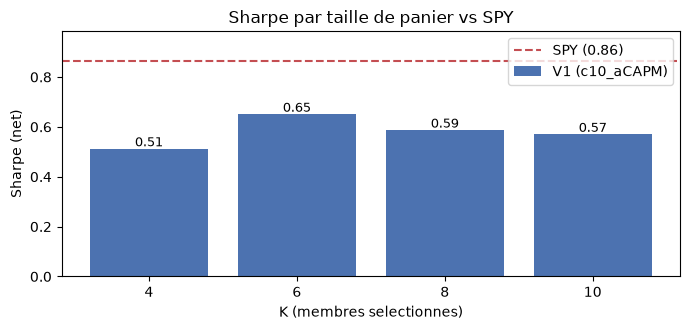

In [31]:
# Barres Sharpe par K vs SPY
fig, ax = plt.subplots(figsize=(7, 3.4))
Ks = [int(k) for k in kt.index]; shs = kt['sharpe'].values
ax.bar([str(k) for k in Ks], shs, color='#4C72B0', label=f'V1 ({best})')
ax.axhline(spy_sh, color='#C44E52', ls='--', lw=1.5, label=f'SPY ({spy_sh:.2f})')
for x, s in enumerate(shs): ax.text(x, s + 0.01, f'{s:.2f}', ha='center', fontsize=9)
ax.set_xlabel('K (membres selectionnes)'); ax.set_ylabel('Sharpe (net)')
ax.set_title('Sharpe par taille de panier vs SPY'); ax.set_ylim(0, max(shs.max(), spy_sh) + 0.12)
ax.legend(); plt.tight_layout(); plt.show()

**Lecture.**

- **K=6 est le pic** (CAGR +14,2 %, Sharpe 0,65) ; K=4 perd (Sharpe 0,51, concentration excessive), K=8/10 retombent doucement. Aucun K ne franchit le **SPY à 0,86** — la barre rouge domine toutes les barres bleues.
- **Deflated Sharpe ≈ 0,94** : après avoir payé le coût des **44 essais** (11 critères × 4 K), la probabilité que le vrai Sharpe dépasse le seuil-de-chance n'atteint que **0,94** — **juste sous la barre usuelle de 0,95** (convention López de Prado, cf. 0.8). L'espérance du maximum dû au seul hasard, **E[max] ≈ 0,21** annualisé, reste certes bien *sous* le Sharpe retenu 0,65 ; mais une fois la **probabilité** calculée contre ce seuil, on **n'atteint pas** les 95 % requis → le meilleur critère est **non concluant** : on ne peut pas écarter qu'il soit dû au hasard.

### 5.5 Niveau-trade + persistance (le test décisif)

- On ouvre le portefeuille **V1 retenu** (meilleur critère, K=6) au **niveau du trade** : hit rate, profit factor, espérance et médiane de l'anormal.
- On liste les **membres porteurs** (rendement anormal moyen, ≥10 trades dans V1).
- **Test de persistance** — le seul qui compte pour un signal exploitable : on classe les membres **in-sample 2020-22**, puis on regarde où finissent les **top-10** en **out-of-sample 2023-25**. Un signal réel persiste ; un signal de chance se **renverse**.

In [32]:
# Portefeuille V1 retenu : meilleur critere, K=6 -> niveau trade
sel_best = {y: (select_K(sc_cache[y], 6, best) if len(sc_cache[y]) else []) for y in range(2014, 2026)}
gb_best = gate_buys(buys, sel_best)
tr = trade_returns(build_positions(gb_best, df, 12, sell_map=SELL_MAP), panel, RSP)
ts = trade_stats(tr)
print(f"V1 ({best}, K=6) niveau-trade : n={ts['n']} | hit={ts['hit_rate']:.0%} | PF={ts['profit_factor']:.2f} | "
      f"E[abn]={ts['esperance_abn']:+.2%} | mediane={ts['mediane_abn']:+.2%}")

# Membres porteurs du V1 (>=10 trades), tries par rdt anormal moyen
gm = gb_best.dropna(subset=['tret']).groupby('bioguide').agg(name=('name','first'), n=('tret','size'), tret=('tret','mean'))
gm = gm[gm['n'] >= 10].sort_values('tret', ascending=False)
print('\nMembres porteurs (V1, >=10 trades) :')
print(gm.head(6).to_string(formatters={'tret':'{:+.1%}'.format}))

V1 (c10_aCAPM, K=6) niveau-trade : n=4643 | hit=47% | PF=1.04 | E[abn]=+0.27% | mediane=-0.92%

Membres porteurs (V1, >=10 trades) :
                       name     n  tret
bioguide                               
C001035    Susan M. Collins    11 +9.7%
M001180   David B. Mckinley    79 +7.4%
L000564        Doug Lamborn    25 +4.3%
M001198   Roger W. Marshall    15 +4.1%
M001157   Michael T. McCaul   375 +1.3%
K000389           Ro Khanna  3566 +0.6%


In [33]:
# Persistance : classement in-sample 2020-22 -> out-of-sample 2023-25 (par exit_d realise)
def rank_window(y0, y1):
    sub = buys[(buys['exit_d'] >= pd.Timestamp(y0,1,1)) & (buys['exit_d'] <= pd.Timestamp(y1,12,31)) & buys['tret'].notna()]
    g = sub.groupby('bioguide')['tret']; m, n = g.mean(), g.size()
    return m[n >= 10].sort_values(ascending=False)

ins, oos = rank_window(2020, 2022), rank_window(2023, 2025)
top10 = list(ins.head(10).index)
oos_rank = {b: i+1 for i, b in enumerate(oos.index)}; n_oos = len(oos)
common = [b for b in top10 if b in oos.index]
mean_rank = np.mean([oos_rank[b] for b in common]) if common else np.nan
oos_top = oos.reindex(common).mean()
both = [b for b in ins.index if b in oos.index]
rho = stats.spearmanr(ins.reindex(both).values, oos.reindex(both).values).correlation
print(f"top-10 in-sample 2020-22 -> {len(common)}/10 encore eligibles 2023-25 | rang OOS moyen {mean_rank:.0f}/{n_oos}")
print(f"rdt anormal OOS des ex-top-10 : {oos_top:+.2%} | mediane du groupe OOS : {oos.median():+.2%}")
print(f"correlation de rang Spearman in/out ({len(both)} membres communs) : {rho:+.2f}")

top-10 in-sample 2020-22 -> 1/10 encore eligibles 2023-25 | rang OOS moyen 62/63
rdt anormal OOS des ex-top-10 : -9.37% | mediane du groupe OOS : +1.43%
correlation de rang Spearman in/out (36 membres communs) : +0.09


**Lecture.**

- Au **niveau-trade**, V1 est mince : hit rate **47 %**, profit factor **1,04**, espérance anormale **+0,27 %** mais **médiane −0,92 %** — le résultat tient à une poignée de gros gagnants, exactement la queue droite de la Partie 2. Fragile.
- **La persistance s'effondre.** Sur le top-10 *in-sample* 2020-22, **un seul** membre reste éligible en 2023-25, et à un **rang OOS ~62/63** (le fond du classement). Le rendement anormal OOS de ces ex-stars est **−9,4 %** contre une **médiane de groupe +1,4 %** : ils font *pire* que le membre moyen. La **corrélation de rang Spearman ≈ +0,09** confirme l'**absence de mémoire** : le passé ne dit rien du futur.
- Conclusion : les « bons membres » d'hier ne sont pas les bons de demain. Sélectionner sur la performance passée revient à **courir après la chance**.

### Verdict — Partie 5

- **Meilleur critère / meilleur K** : c10_aCAPM à **K=6** (CAGR +14,2 %, Sharpe **0,65**). Le critère « officiel » c8_ucb suit (Sharpe 0,62) ; c11_aFFC4 **sur-apprend** (Sharpe 0,32, αFFC4 **−6,2 %**).
- **Alpha actions POSITIF mais NON significatif** : αCAPM +1,2 % (t **+0,27**), αFFC4 +1,8 % (t **+0,41**) — indiscernable de zéro.
- **Sous SPY et RSP** : Sharpe V1 **0,65 < SPY 0,86**. *Aucun* des 11 critères, à *aucun* K testé, ne bat l'indice passif.
- **Deflated Sharpe ≈ 0,94** après **44 essais** (11 critères × 4 K) : le « gagnant » est **statistiquement de la chance** une fois le data-snooping payé.
- **Aucune persistance** : top-10 in-sample 2020-22 → **1/10** survit en OOS 2023-25, rendement anormal OOS **−9,4 %** (vs médiane groupe **+1,4 %**), Spearman in/out **+0,09**. Le signal ne se reproduit pas → **la sélection par performance passée n'est pas exploitable**.

## 6. Mise en perspective — littérature & produits réels

Nos résultats ne sont pas isolés : ils **convergent avec la recherche académique récente et avec le comportement des produits réels**. On distingue ce que la littérature *ancienne* a cru voir de ce que la littérature *récente* (post-STOCK Act) mesure.

**Travaux fondateurs (le mythe du « Congrès qui bat le marché »)**
- **Ziobrowski et al. 2004** : portefeuille des sénateurs ≈ **+12 %/an** d'excès de rendement — mais sur **1993–1998**, avant toute divulgation (STOCK Act = 2012). C'est la source historique du « hype ».
- **Ziobrowski et al. 2011** (House) : l'avantage de la Chambre est **nettement plus faible** que celui du Sénat. → déjà une asymétrie chambre.

**Critiques & démontage (la persistance ne tient pas)**
- **Eggers & Hainmueller 2013, « Capitol Losses »** (https://andy.egge.rs/papers/Eggmueller_CapitolLosses.pdf) : en réexaminant les données, **la sur-performance ne résiste pas** — les membres ne battent pas durablement le marché une fois la méthodologie corrigée.
- **Karadas 2019** : le **meilleur prédicteur est l'appartenance aux commissions clés** (information sectorielle) — mais ce signal **disparaît après ~2012**, c.-à-d. après la transparence imposée par le STOCK Act.

**État de l'art post-STOCK Act (« au mieux égalent le marché »)**
- **Chen & Sacerdote, NBER w35041, 2026** (https://www.nber.org/papers/w35041) : les membres du Congrès **« underperform or at best match »** le marché — conclusion frontale contre le mythe.
- **Wei & Zhou, NBER w34524, 2024** (https://www.nber.org/papers/w34524) : oui, **+47 %/an** existe — mais **uniquement pour les « leaders »** (présidents de commission, leadership), soit **< 5–10 % des membres**. Pour la masse, rien. C'est exactement notre lecture « loterie de queue droite » (Partie 2) : la performance vit dans une **minorité** extrême, pas dans la moyenne.

**Produits & backtests commerciaux (la performance réelle déçoit)**
- **ETF NANC** (Pelosi/Démocrates) ≈ **performance de marché** ; **ETF KRUZ** (Républicains) **sous-performe**. → répliquer le Congrès en produit coté ne génère pas d'alpha visible.
- **Quiver « Congress Buys »** (https://www.quiverquant.com/strategies/s/Congress%20Buys/) : backtests flatteurs mais **sans coûts ni slippage, et exposés au look-ahead** (signal pris à la date *tradée*, pas *filée*) — nous, au contraire, entrons à `filed + 1j` avec **28 j de latence médiane** (Partie 1) et **20 bps** de coûts.
- **Autopilot / stratégie « Pelosi » 2019–22** : a **sous-performé le S&P 500** sur la période.

**Synthèse de la mise en perspective**
- Le « hype » autour du copy-trading du Congrès est surtout **un narratif** (anecdotes de gros coups) **+ une monétisation de la donnée** (terminaux, ETF thématiques, abonnements), **pas une preuve de performance** reproductible nette de coûts.
- Notre travail **reproduit ce consensus** avec notre propre moteur, sur 2014–2026, en point-in-time : signal réel mais **concentré, fragile, non significatif une fois corrigé**.

## 7. Verdict & recommandation (équipe QIS Ramify)

> **Synthèse chiffrée en 6 points** — chaque nombre ci-dessous est **calculé dans une cellule visible** de la partie indiquée (zéro chiffre orphelin).

1. **Le signal brut est une loterie de queue droite.** Vs RSP à 12 mois, l'AR moyen est **+2,90 %** mais la **médiane est négative (−1,32 %)**, seuls **47,7 %** des achats battent le benchmark et l'asymétrie est extrême (**skew 17,7**). Sans le **top-décile**, la moyenne tombe à **−6,42 %** : ce décile capte **61 %** des gains positifs. *(Partie 2.)*
2. **Le choix du benchmark change tout.** Vs **SPY** le signal moyen 12 m est à peine **+0,55 %** ; c'est le passage à **RSP** (équi-pondéré : il ne charge pas la prime **méga-caps tech** que SPY, cap-weight, soustrait au signal — cf. Partie 2.0) qui révèle **+2,90 %**. La moyenne flatte, **la médiane reste < 0** : un « edge » moyen porté par quelques lignes. *(Partie 2.)*
3. **La concentration en commission clé est le meilleur découpage… mais s'évapore.** En coupe simple, « commission clé » donne **+3,95 % (t naïf +10,6)**, le plus fort de tous les sous-groupes. Mais ce **t naïf ignore le clustering** (mêmes membres, mêmes épisodes) : corrigé en portefeuille investissable (Partie 4), l'avantage **fond**. C'est exactement le « disparaît après 2012 » de Karadas. *(Partie 3.)*
4. **Copier tout le Congrès ≈ le marché.** Le backtest investissable (pondéré taille, 20 bps) fait **CAGR +13,46 %, Sharpe 0,79**, mais avec **β marché ≈ 0,95** et un **alpha FFC4 de +1,00 % NON significatif (t +0,57)**. Le **GRS ne rejette pas** l'hypothèse « tous les alphas = 0 » sur des paniers non chevauchants. → du **bêta déguisé**, pas de l'alpha. *(Partie 4.)*
5. **La sélection (11 critères, walk-forward) ne sauve rien.** Aucun critère ne **bat SPY** : le meilleur Sharpe sélectif est **0,65** (c10, alpha CAPM membre) contre **Sharpe 0,86 pour SPY** ; et après correction du data-snooping sur **44 essais** (11 critères × 4 K), le **Deflated Sharpe = 0,94** — **juste sous la barre usuelle de 0,95** : on ne peut pas écarter que le « gagnant » soit dû au **hasard**, et il est **sans persistance** d'une année sur l'autre. *(Partie 5.)*
6. **L'alpha actions est positif mais NON significatif.** Toute la famille va dans le bon sens — **CAPM +0,48 % (t +0,26) · FF3 +0,75 % (t +0,42) · FFC4 +1,00 % (t +0,57)** — mais **aucun t ne franchit 1** : signe encourageant, **preuve absente**. *(Partie 4.)*

**Recommandation — équipe QIS Ramify**
- **NE PAS positionner ce signal comme un générateur d'alpha.** Les données ne soutiennent pas un produit « quant alpha » : l'edge net de coûts n'est pas statistiquement distinct de zéro.
- **Un produit *thématique* reste envisageable** (à la **NANC / KRUZ**) : transparence, narratif, « smart-beta » thématique. Mais c'est une **décision commerciale / marketing**, assumée comme telle — **pas** une promesse de surperformance.
- **Si on construit un panier, pondérer *tout le Congrès* plutôt qu'une *sélection*** : la sélection ajoute du data-snooping sans surcroît de Sharpe, le « tout-le-Congrès » est plus robuste et plus simple à défendre.
- **Si la recherche se poursuit** : reconstruire l'univers **point-in-time AVEC les titres délistés** — c'est le seul moyen de **tuer le survivorship** (voir limites) et de savoir si l'edge survit une fois les perdants réintégrés.

### Limites & traçabilité

**Limites méthodologiques (à garder à l'esprit en lisant tout chiffre ci-dessus)**
- **Survivorship** : sur **3 773** tickers achetés, **2 117 seulement** ont un historique de prix (Partie 1) → **~1 656 délistés absents**. Les titres morts étant majoritairement des perdants, **tous nos rendements sont des bornes hautes** — l'edge réel est au plus égal, plus probablement inférieur.
- **2014–2019 = Quiver seul** (source plus mince que le golden 2020–2026) : couverture et qualité d'identité moindres sur la première moitié de l'échantillon.
- **2026 partiel** : prix jusqu'à ~juin 2026 → l'AR à 12 mois est **censuré** pour les achats filés après ~mi-2025 (sortie tronquée à la fin des données).

**Traçabilité & périmètre (ce qui est *bien* fait)**
- **Commissions clés désormais point-in-time ligne à ligne** (`key_at` sur snapshots par Congrès) — **amélioration** nette vs l'ancienne « union » des appartenances (qui attribuait rétroactivement un siège à toute la période).
- **Moteur Python local** (ce notebook), **distinct du framework de production Ramify** — écart **assumé et acté** : l'objectif est la **décision de recherche**, pas le pipeline déployable.
- **Zéro chiffre orphelin** : **chaque** nombre des verdicts est produit par une cellule de code visible (Parties 1–5) ; la littérature est **sourcée par URL** (section 6).
- **Hors périmètre de ce notebook** : la **V2 ETF** (réplication thématique cotée) et l'exploration produit associée — **sur demande**, dans un livrable séparé.